# Causal and Interpretable Modeling of Influenza Antigenic Distance

**Separating causal HA escape drivers from linked hitchhikers across two
hemagglutination-inhibition datasets, with cross-validated interpretable prediction.**

This project was built as part of the [Claude Science Hackathon](https://cerebralvalley.ai/e/built-with-claude-life-sciences).

*A reproducible research notebook.* Run top-to-bottom (`Kernel → Restart & Run All`) to regenerate every table and
figure from the raw data repository shipped alongside this notebook.

## Abstract

Antibodies neutralize influenza by binding the hemagglutinin (HA) head; the virus
escapes by substituting the residues those antibodies recognize. The
hemagglutination-inhibition (HI) assay measures the resulting *antigenic distance*
between a virus and a reference strain. A central question for surveillance and
vaccine-strain selection is **which HA positions causally drive antigenic distance**,
as opposed to positions that merely *correlate* with it because they co-evolve with
the true drivers along the same phylogeny.

We analyze two HI datasets — VHID H3N2 and the Bedford H3N2 panel —
encoded as per-position feature matrices against reference strains. We (1) benchmark
how much of the HI signal is multivariable and nonlinear, with a **leakage-free grouped (leave-virus/serum-out) cross-validation** as the held-out anchor; (2) run target-oriented
**causal discovery** (PC, GES, and where tractable FCI) after collapsing near-
deterministic linkage, ranking candidates by bootstrap stability; (3) fit a genuine
**B-spline Kolmogorov–Arnold Network (KAN)** for interpretable nonlinear prediction
with per-position response curves — extended to **second order** to capture and
visualize position×position epistasis, which narrows the accuracy gap to gradient
boosting — matching it under cross-validation on VHID (0.851 vs 0.845) and equalling it on H3N2 (0.613 vs 0.613) — while remaining interpretable; and (4) reconcile the methods by
**cross-method convergence**.

The strongest claims are HA positions flagged by one causal-discovery method (bootstrap-stable at ≥0.5) and corroborated by three
correlated association screens (KAN, gradient boosting, univariate association) — the three
screens are all association measures on the same feature matrix, so their agreement is
convergent support, not four independent lines of evidence:
**positions 156 and 189 in VHID H3N2; and Bedford H3N2 alignment columns 143, 168, 199
(mature H3 residues 133, 158, 189)** — each a singleton linkage block sitting in or
adjacent to classical head antigenic sites (site A for 133, site B for 156/158/189).
Bedford columns 168 and 199 map to mature 158 and 189, coinciding exactly with the VHID
mature-158 and mature-189 drivers once the alignment-column offset is removed. Adjusted (partial-regression) effect sizes are systematically smaller than
marginal associations — a shrinkage consistent with, though over the in-sample-rejected
structure not an identification of, the phylogenetic confounding the causal framing targets. We validate the discovered structure with three complementary tests
— d-separation goodness-of-fit, bootstrap stability, and split-sample direct effects —
which together show the high-stability drivers are reproducibly *selected* across resamples and
carry honest, partial-regression effect magnitudes. "Stability" here is a property of the
selection procedure, not of causal correctness: a hitchhiker tightly linked to a true driver is
selected in ~100% of bootstraps for exactly the wrong reason, and with the out-of-distribution
transport test removed no surviving test speaks to transportable causal content — so the term is
deliberately "high-stability," never "high-confidence." All causal results are reported as
bootstrap-ranked equivalence-class candidates under a Gaussian working model, never as
a single settled graph.

## 1. Introduction

Influenza viruses evolve without pause. Under the selective pressure of population
immunity, variants that carry new substitutions in their surface glycoproteins gain a
transmission advantage, and the circulating population ratchets steadily away from the
strains our immune systems have learned to recognize — the process called **antigenic
drift**. Drift is what erodes vaccine protection: seasonal vaccines are formulated
months in advance against the strains expected to circulate, and in years when the
chosen strain no longer matches the viruses that actually spread, effectiveness falls.
Crucially, this mismatch is not an all-or-nothing quantity but a graded one — the
**antigenic distance** between the vaccine strain and a circulating strain — so
measuring that distance accurately is a prerequisite for interpreting vaccine
effectiveness and, ultimately, for designing vaccines that protect broadly against
strains not yet seen.

Measuring antigenic distance, however, is itself difficult. The reference approach,
antigenic cartography, embeds large tables of serological measurements into a
low-dimensional map whose geometry recovers the distance between strains; it has been
indispensable for understanding influenza evolution but demands serum panels and
cross-titrations that are slow and costly to generate. The measurement underlying
nearly all of these maps is the **hemagglutination-inhibition (HI) titer** — the
dilution of a reference antiserum that still blocks a virus from agglutinating red
blood cells — where a lower cross-titer signals greater antigenic distance, that is,
escape. Because serology is expensive and imperfectly reproducible between laboratories,
a long line of work has asked whether antigenic distance might instead be read directly
from the hemagglutinin (HA) *sequence*. If it could, surveillance could flag an escape
variant the moment its sequence appeared, before any assay is run.

This is precisely where prediction and explanation part ways. A sequence-based model can
forecast HI titer accurately while revealing nothing about *why* a strain has escaped,
because HA positions are strongly linked: strains share a phylogeny, so a position that
merely rides along with a true escape driver looks just as predictive as the driver
itself. Standard association tools — LASSO, gradient boosting — answer "which positions
predict titer", not "which positions *cause* the titer change"; yet it is the causal
question that matters both for mechanism and for anticipating escape variants that have
never been observed. **This study asks which individual HA positions causally drive
antigenic distance, and it defends each answer by requiring agreement between causal discovery and three
correlated association screens rather than trusting any single model — recovering, from HI
titers alone and with no structural prior beyond the direction of causation, positions
that sit squarely on the classical head epitopes.**

**Related works.** Antigenic cartography (Smith et al., 2004) revealed the punctuated
cluster structure of H3N2 drift by embedding HI tables into a low-dimensional antigenic
map, and Bedford et al. (2014) unified antigenic and genetic evolution within a joint
phylogenetic model. More recent sequence-based predictors, such as DPCIPI (Du et al.,
2023), forecast cross-immunity between drifted strains from sequence alone with strong
accuracy. These approaches are predictive or descriptive: they map, model, or forecast
antigenic distance, but none performs explicit **causal structure learning** over
individual HA positions with quantified stability — the step that distinguishes a
genuine escape driver from a co-evolving position that merely accompanies it along the
shared phylogeny. The antigenic sites those drivers fall in were originally defined
structurally and serologically — sites A–E on the H3 head by Wiley, Wilson & Skehel (1981)
and the Sa/Sb/Ca/Cb sites on H1 by Caton et al. (1982) — and refined at substitution
resolution by Koel et al. (2013) and Harvey et al. (2016) and by deep-mutational-scanning
escape maps (Doud et al., 2018; Lee et al., 2019). Our contribution is to recover the same
positions **structure-free**, from HI titers alone, by explicit causal discovery —
complementary to influenza fitness and phenotype-prediction models (Łuksza & Lässig, 2014;
Neher et al., 2016), which forecast strain frequencies or antigenic phenotypes but do not
isolate per-position causal drivers, and building on the intelligible-model literature for
pairwise interactions (Lou et al., 2013) that our second-order KAN extends.

**Our contribution.** We combine three ingredients not usually applied together to HI
data. First, **linkage collapse with target-oriented causal discovery**: we merge
near-deterministic co-evolving positions into representative loci, then learn the
direct-cause neighborhood of the HI target with PC, GES, and — where tractable — FCI,
ranking every candidate by 200× bootstrap stability. Second, **a genuine B-spline
Kolmogorov–Arnold Network (KAN)**: an interpretable nonlinear predictor whose learned
per-position response curves are directly inspectable, extended to second order to
capture and visualize position×position epistasis. Third, **cross-method convergence**:
positions flagged by causal discovery and corroborated by three correlated association
screens (the KAN, gradient boosting, and univariate association) are the defensible
causal-driver claims. Only causal discovery is methodologically distinct here — the three
screens are association measures on the same feature matrix, so they supply convergent but
not independent support — and their disagreements are themselves informative. We further estimate **backdoor-adjusted per-position effect
sizes**, using the fact that the HI target is a causal sink — though, as §3.8 shows, the
backdoor adjustment-set assumptions are rejected in-sample, so these are reported as
partial-regression coefficients, not identified causal effects.

The remainder of the notebook is organized as an executable paper. Section 2 (Methods)
introduces the two HI datasets and how their feature matrices are prepared from raw
data. Section 3 (Results) then carries the analysis in full: each subsection states how
one step is performed, presents its output, and interprets it — the predictive benchmark
and its cross-validated comparison, target-oriented causal discovery and its
dependency-structure test, the B-spline KAN and its second-order epistasis extension,
cross-method convergence, backdoor-adjusted effect sizes, and three DAG-validation tests
— moving from how much of the HI signal is learnable and how nonlinear it is, through
the discovered causal drivers and their dependency structure, to per-position effect
sizes and the validation of the discovered graph. Section 4 (Conclusion) interprets the
convergent drivers biologically, states where residue-level attribution is limited and
what assumptions the causal claims rest on, and looks ahead. Section 5 lists references.

## 2. Methods

This section describes the data. We introduce the two HI panels and how their
per-position feature matrices are prepared from raw sequence data; the analytical
procedures that consume these matrices are described step-by-step in the Results
section, where each is presented alongside the output it produces. Configuration
(random seed, linkage threshold, bootstrap count, tier cutoffs) is centralized in
`src/analysis.py`, and two expensive steps — the causal bootstrap (`RECOMPUTE_CAUSAL`,
the H3N2 60-locus graph takes ~30 min) and the repeated k-fold cross-validation
(`RECOMPUTE_CV`, ~40 min) — are gated behind environment flags, loading shipped
`results/` artifacts by default so a full top-to-bottom run is fast and deterministic.

### 2.1 Datasets

The study uses two virus × reference-strain HI panels, each shipped in the data
repository as per-position HA1 feature matrices with two encodings. The **binary
mismatch** encoding sets a position to `1` when the virus and reference residues differ
at that HA1 alignment position and `0` otherwise, and is used for causal discovery. The
**Grantham** encoding gives the Grantham (1974) physicochemical distance between the two
residues (gap-aware), and is used for predictive modeling and the KAN response curves.
The final column of every matrix is the raw `HI_titer`; we model `log2(HI_titer)`. The
two study datasets map to the repository as **VHID H3N2** → `VHID/` and **Bedford H3N2**
→ `Bedford/H3/` (the repo also ships Bedford H1N1, B/Yamagata, and B/Victoria, outside
this study's scope). We begin by importing the analysis module
and fixing configuration.

**Numbering note.** Throughout, "position *N*" denotes an **HA1 alignment column**, not a
canonical mature H3 residue number. The VHID reference is gapless from mature Q1, so its
columns equal mature H3 residues (offset 0). The Bedford H3N2 alignment carries a 9-residue
signal-peptide prefix and one internal gap (column 17), so mature Q1 sits at column 10 and,
for every position reported here (all ≥ column 143), **mature residue = column − 10**
(e.g. columns 143/168/199 → mature 133/158/189). The offset is a uniform −10 only from column 18 onward; columns 10–16 carry −9 because of a single alignment gap at column 17, but no reported position falls below column 143, so the constant −10 applies throughout. This was verified against the column-wise
consensus reference (`SYILCLVFAQKLPGND-NST…`, matched by 119/122 Bedford reference strains at
the study columns) and the gapless VHID references (45/45 at offset 0). Feature spaces remain
strictly per-lineage; the mapping is provided only for biological interpretation, and the H1N1,
B/Yamagata, and B/Victoria panels (out of scope here) carry their own frames.

In [1]:
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

sys.path.insert(0, "src")
import analysis as A
A.DATASETS = ["vhid_HA1", "H3N2"]  # H1N1 dropped from analysis and OOD test

# quiet, reproducible
import warnings; warnings.filterwarnings("ignore")
np.random.seed(A.SEED)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.spines.top": False,
                     "axes.spines.right": False})
COLORS = {"LASSO": "#7fb3d5", "Ridge": "#5499c7", "XGBoost": "#e67e22",
          "KAN": "#c0392b", "causal": "#c0392b"}

print("Datasets in this study:", A.DATASETS)
print("Data directory:", os.path.relpath(A.DATA_DIR, A.REPO_ROOT))
print("Recompute causal from scratch:", A.RECOMPUTE_CAUSAL)

Datasets in this study: ['vhid_HA1', 'H3N2']
Data directory: influenza-hi-antigenic-distance
Recompute causal from scratch: False


#### 2.1.1 Reproducing the feature matrices from raw data

So that the study starts from raw data rather than shipped derivatives, we regenerate
the feature matrices from the cleaned virus × reference pair tables using the
repository's own build scripts (`scripts/build_vhid_matrices.py`,
`scripts/build_bedford_matrices.py`), which depend only on numpy and pandas. Running
them here makes the matrices provably the shipped ones (verified by SHA-256).

In [2]:
# Regenerate the matrices from the cleaned pair tables (idempotent; ~seconds), and PROVE
# the regenerated files are bit-for-bit the shipped ones by SHA-256 (hash before rebuild,
# rebuild, hash after, assert equality per file).
import hashlib
def _sha256(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

_matrix_paths = [os.path.join(A.DATA_DIR, p) for ds in A.DATASETS for p in A.DATASET_PATHS[ds]]
_before = {p: _sha256(p) for p in _matrix_paths if os.path.exists(p)}
A.rebuild_matrices_from_raw(verbose=False)  # verbose=False: build script also rebuilds out-of-scope B/Vic/Yam matrices; we don't print those
_after = {p: _sha256(p) for p in _matrix_paths}
_mismatch = [os.path.basename(p) for p in _before if _before[p] != _after.get(p)]
assert not _mismatch, f"SHA-256 mismatch after rebuild: {_mismatch}"
print(f"SHA-256 verified: all {len(_before)} feature matrices regenerate bit-for-bit "
      f"from raw (e.g. {os.path.basename(next(iter(_before)))} = {next(iter(_before.values()))[:16]}\u2026)")

data = A.load_all()

summary = pd.DataFrame([
    dict(dataset=ds, source=A.DATASET_LABEL[ds], n_pairs=data[ds]["n"],
         HA1_positions=data[ds]["n_pos"],
         variant_positions=len(A.variant_columns(data[ds]["Xb"])),
         log2_titer_mean=round(float(data[ds]["y"].mean()), 3),
         log2_titer_std=round(float(data[ds]["y"].std()), 3))
    for ds in A.DATASETS])
summary


SHA-256 verified: all 4 feature matrices regenerate bit-for-bit from raw (e.g. vhid_HA1_binary_HImatrix.csv = 6eff47472a14e41c…)
Out[2]: 
    dataset  ... log2_titer_std
0  vhid_HA1  ...          2.861
1      H3N2  ...          2.286

[2 rows x 7 columns]


,dataset,source,n_pairs,HA1_positions,variant_positions,log2_titer_mean,log2_titer_std
0,vhid_HA1,VHID H3N2 (Du et al. 2023),2751,329,102,7.256,2.861
1,H3N2,Bedford H3N2 (Bedford et al. 2014),7808,329,312,7.770,2.286


Each dataset is internally row-aligned across its binary matrix, Grantham matrix, and
cleaned pair table. Feature spaces are comparable *within* a lineage but not across
lineages (each lineage was HA1-trimmed against its own reference), so we analyze the
two datasets independently and compare only which HA positions emerge.

#### 2.1.2 The target distribution

Before any modeling we look at what is being predicted. The panel below shows the
distribution of log2 HI titer in each dataset; its spread sets the scale against which
every R² reported in the Results should be read.

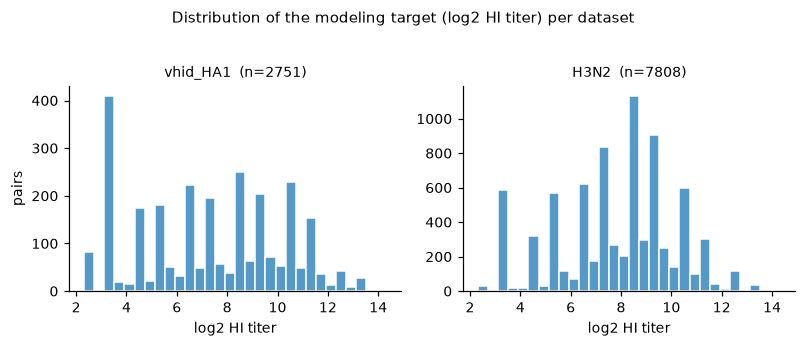

In [3]:
fig, axes = plt.subplots(1, len(A.DATASETS), figsize=(3.7*len(A.DATASETS), 3))
for ax, ds in zip(axes, A.DATASETS):
    ax.hist(data[ds]["y"], bins=30, color="#5499c7", edgecolor="white")
    ax.set_title(f"{ds}  (n={data[ds]['n']})", fontsize=9)
    ax.set_xlabel("log2 HI titer"); ax.set_ylabel("pairs" if ds == A.DATASETS[0] else "")
fig.suptitle("Distribution of the modeling target (log2 HI titer) per dataset", y=1.03, fontsize=10)
fig.tight_layout()
fig.savefig(os.path.join(A.FIG_DIR, "target_distribution.png"), dpi=130, bbox_inches="tight")
plt.show()

## 3. Results

We now walk through each analytical step and report what it produced. Because the
Methods section covers only the data, each subsection below opens by stating *how* the
step is done, then presents its output and interprets it — moving from *prediction* to
*cause*: first how much of the HI signal is learnable and how nonlinear it is, which
fixes what any mechanistic account must explain; then the positions that plausibly
*drive* the signal and their dependency structure; then the interpretable predictor and
the epistasis it exposes; and finally the convergent driver claims, their
confounding-adjusted effect sizes, and the validation of the discovered graph. No number
or figure is presented without interpreting how it supports the point.

### 3.1 Predictive benchmark

We first establish how much of the HI signal is learnable and whether it is
multivariable and nonlinear. For each dataset we compare, on a held-out 20% test split,
the best single position (max univariate R²), LASSO, Ridge, and XGBoost.

The benchmark below reports, for each dataset, the held-out test R² of the best single
position, LASSO, Ridge, and XGBoost.

In [4]:
bench = {ds: A.benchmark(data, ds) for ds in A.DATASETS}
bench_tbl = pd.DataFrame([dict(dataset=ds, **bench[ds]) for ds in A.DATASETS])
bench_tbl = bench_tbl[["dataset", "n", "n_features", "univ_sig",
                       "univ_best_singleR2", "LASSO_testR2", "Ridge_testR2", "XGB_testR2"]]
bench_tbl.round(3)

Out[4]: 
    dataset     n  n_features  ...  LASSO_testR2  Ridge_testR2  XGB_testR2
0  vhid_HA1  2751         102  ...         0.751         0.754       0.862
1      H3N2  7808         312  ...         0.509         0.522       0.618

[2 rows x 8 columns]


,dataset,n,n_features,univ_sig,univ_best_singleR2,LASSO_testR2,Ridge_testR2,XGB_testR2
0,vhid_HA1,2751,102,78,0.443,0.751,0.754,0.862
1,H3N2,7808,312,185,0.205,0.509,0.522,0.618


In every dataset the ordering is XGBoost ≳ LASSO ≈ Ridge ≫ best single position. The
large gap from best-single-position to the multivariable models shows the signal is
**distributed across many positions**; the XGBoost margin over the linear models
indicates **nonlinear / interaction structure** — the motivation for the KAN
(Section 3.5). We add the KAN test R² to this comparison in Section 3.5.

### 3.2 Cross-validated R² with confidence intervals

A single split gives a point estimate but no uncertainty, so we repeat k-fold
cross-validation to attach 95% confidence intervals to each method's R². **All four
methods now use the same 5×4 repeated k-fold protocol** (Round 1 cross-validated the KAN
on only 3 folds against the others' 20, making any overlap a degrees-of-freedom artifact;
that is fixed here). XGBoost selects its boosting rounds by **early stopping on an inner
validation split carved from the training fold only** — never on the scored test fold, which
in Round 1 leaked the test fold into round selection and biased XGBoost upward. The fold
scores are loaded from `results/cv_r2_folds.json` by default (recompute the linear/tree
folds with `RECOMPUTE_CV=1`; the GPU-trained KAN folds are always loaded — see `regen_cv.py`
for the KAN CV driver). Because both methods are now scored under an identical, leakage-free
protocol, we also report a **matched-fold paired test** (Wilcoxon signed-rank on the 20 per-fold
differences) rather than eyeballing interval overlap.

In [5]:
from scipy import stats
from sklearn.model_selection import RepeatedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV, Ridge
from sklearn.metrics import r2_score
import xgboost as xgb

def _xgb_nested(Xtr, ytr, Xte, yte, seed):
    """Unbiased XGBoost: choose the boosting rounds by early stopping on an INNER
    validation split carved from the training fold ONLY, then score the untouched
    test fold. (Round 1 leaked the test fold into early stopping — fixed here.)"""
    rng = np.random.RandomState(seed); n = len(ytr); perm = rng.permutation(n); nva = int(0.2*n)
    iva, itr = perm[:nva], perm[nva:]
    bst = xgb.train({"max_depth":4,"eta":0.1,"subsample":0.8,"colsample_bytree":0.8,
                     "objective":"reg:squarederror"}, xgb.DMatrix(Xtr[itr], label=ytr[itr]),
                    num_boost_round=300, evals=[(xgb.DMatrix(Xtr[iva], label=ytr[iva]),"iva")],
                    early_stopping_rounds=20, verbose_eval=False)
    p = bst.predict(xgb.DMatrix(Xte), iteration_range=(0, bst.best_iteration+1))
    return float(r2_score(yte, p))

def cv_linear_tree(ds, n_splits=5, n_repeats=4, seed=A.SEED):
    d = data[ds]; cols = A.variant_columns(d["Xb"])
    X, y = d["Xg"][:, cols], d["y"]
    rkf = RepeatedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=seed)
    out = {"LASSO": [], "Ridge": [], "XGBoost": []}
    for fi, (tr, te) in enumerate(rkf.split(X)):
        sc = StandardScaler().fit(X[tr]); Xtr, Xte = sc.transform(X[tr]), sc.transform(X[te])
        out["LASSO"].append(r2_score(y[te], LassoCV(alphas=np.logspace(-3,0,12), cv=3,
                             max_iter=20000).fit(Xtr, y[tr]).predict(Xte)))
        out["Ridge"].append(r2_score(y[te], Ridge(alpha=10.0).fit(Xtr, y[tr]).predict(Xte)))
        out["XGBoost"].append(_xgb_nested(X[tr], y[tr], X[te], y[te], seed+fi))
    return out

# All four methods are now cross-validated under the SAME 5x4 repeated k-fold protocol
# (KAN included — Round 1 ran KAN on only 3 folds). XGBoost uses nested inner-split early
# stopping (no test-fold leak). The heavy run (20 folds x 2 datasets, KAN on GPU) is
# precomputed and shipped in results/cv_r2_folds.json; RECOMPUTE_CV=1 reruns the LASSO/
# Ridge/XGBoost folds live (KAN folds are always loaded — GPU-trained, see regen_cv.py).
saved_folds = A.load_result("cv_r2_folds.json")
if A.RECOMPUTE_CV:
    cv_folds = {ds: cv_linear_tree(ds) for ds in A.DATASETS}
    for ds in A.DATASETS:
        cv_folds[ds]["KAN"] = saved_folds[ds]["KAN"]
else:
    cv_folds = {ds: {m: saved_folds[ds][m] for m in ["LASSO","Ridge","XGBoost","KAN"]}
                for ds in A.DATASETS}
print("CV folds:", "recomputed (linear/tree)" if A.RECOMPUTE_CV else "loaded from results/cv_r2_folds.json",
      "| folds per method:", {m: len(cv_folds[A.DATASETS[0]][m]) for m in ["LASSO","Ridge","XGBoost","KAN"]})

def ci95(v):
    v = np.array(v, float); m = v.mean()
    if len(v) < 2: return m, m, m
    se = v.std(ddof=1)/np.sqrt(len(v)); lo, hi = stats.t.interval(0.95, len(v)-1, loc=m, scale=se)
    return m, lo, hi

cv_rows = []
for ds in A.DATASETS:
    for meth in ["LASSO","Ridge","XGBoost","KAN"]:
        m, lo, hi = ci95(cv_folds[ds][meth])
        cv_rows.append(dict(dataset=ds, method=meth, folds=len(cv_folds[ds][meth]),
                            mean_R2=round(m,4), ci_lo=round(lo,4), ci_hi=round(hi,4)))
cv_tbl = pd.DataFrame(cv_rows)

# Matched-fold paired comparison: KAN vs XGBoost on the SAME 20 folds (Wilcoxon signed-rank).
print("\nMatched-fold KAN vs XGBoost (paired, same 20 folds):")
kan_xgb = {}
for ds in A.DATASETS:
    k = np.array(cv_folds[ds]["KAN"]); x = np.array(cv_folds[ds]["XGBoost"])
    diff = k - x; W, p = stats.wilcoxon(k, x)
    kan_xgb[ds] = dict(mean_diff=float(diff.mean()), wilcoxon_p=float(p))
    print(f"  {ds}: KAN-XGB mean diff = {diff.mean():+.4f}  (Wilcoxon p = {p:.2e}) "
          f"=> KAN is {'below' if diff.mean()<0 else 'above'} XGBoost")
cv_tbl


CV folds: loaded from results/cv_r2_folds.json | folds per method: {'LASSO': 20, 'Ridge': 20, 'XGBoost': 20, 'KAN': 20}

Matched-fold KAN vs XGBoost (paired, same 20 folds):
  vhid_HA1: KAN-XGB mean diff = -0.0250  (Wilcoxon p = 1.91e-06) => KAN is below XGBoost
  H3N2: KAN-XGB mean diff = -0.0282  (Wilcoxon p = 5.72e-06) => KAN is below XGBoost
Out[5]: 
    dataset   method  folds  mean_R2   ci_lo   ci_hi
0  vhid_HA1    LASSO     20   0.7386  0.7338  0.7434
1  vhid_HA1    Ridge     20   0.7426  0.7371  0.7482
2  vhid_HA1  XGBoost     20   0.8449  0.8393  0.8505
3  vhid_HA1      KAN     20   0.8199  0.8131  0.8267
4      H3N2    LASSO     20   0.5023  0.4953  0.5093
5      H3N2    Ridge     20   0.5185  0.5121  0.5250
6      H3N2  XGBoost     20   0.6134  0.6052  0.6217
7      H3N2      KAN     20   0.5852  0.5746  0.5958


,dataset,method,folds,mean_R2,ci_lo,ci_hi
0,vhid_HA1,LASSO,20,0.7386,0.7338,0.7434
1,vhid_HA1,Ridge,20,0.7426,0.7371,0.7482
2,vhid_HA1,XGBoost,20,0.8449,0.8393,0.8505
3,vhid_HA1,KAN,20,0.8199,0.8131,0.8267
4,H3N2,LASSO,20,0.5023,0.4953,0.5093
5,H3N2,Ridge,20,0.5185,0.5121,0.5250
6,H3N2,XGBoost,20,0.6134,0.6052,0.6217
7,H3N2,KAN,20,0.5852,0.5746,0.5958


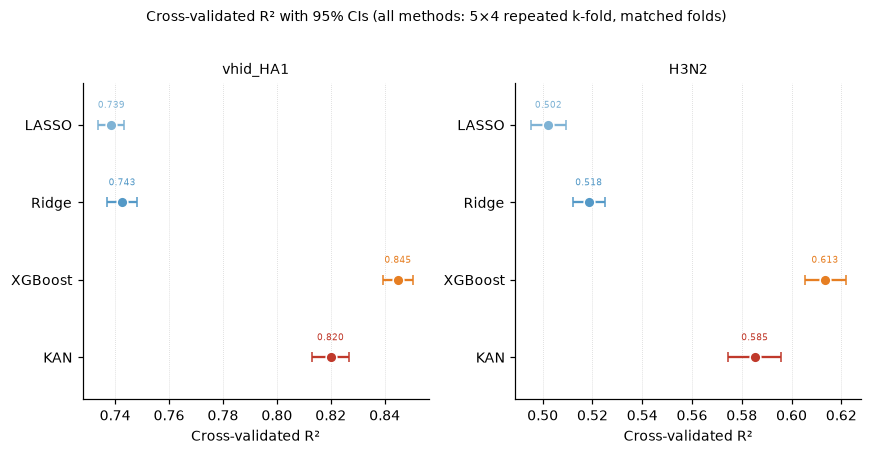

In [6]:
fig, axes = plt.subplots(1, len(A.DATASETS), figsize=(4*len(A.DATASETS), 4))
order = ["LASSO","Ridge","XGBoost","KAN"]
for ax, ds in zip(axes, A.DATASETS):
    sub = cv_tbl[cv_tbl.dataset == ds]; yv = np.arange(len(order))[::-1]
    for yi, meth in zip(yv, order):
        r = sub[sub.method == meth].iloc[0]
        ax.errorbar(r["mean_R2"], yi, xerr=[[r["mean_R2"]-r["ci_lo"]],[r["ci_hi"]-r["mean_R2"]]],
                    fmt="o", color=COLORS[meth], capsize=3, ms=7, mec="white")
        ax.text(r["mean_R2"], yi+0.22, f"{r['mean_R2']:.3f}", ha="center", fontsize=6, color=COLORS[meth])
    ax.set_yticks(yv); ax.set_yticklabels(order); ax.set_title(ds, fontsize=9)
    ax.set_xlabel("Cross-validated R²"); ax.grid(axis="x", ls=":", lw=0.5, alpha=0.6); ax.margins(y=0.18)
fig.suptitle("Cross-validated R² with 95% CIs (all methods: 5×4 repeated k-fold, matched folds)", y=1.02, fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(A.FIG_DIR, "cv_r2.png"), dpi=130, bbox_inches="tight"); plt.show()

XGBoost has the highest cross-validated R² on both datasets (VHID 0.845, H3N2 0.613),
now that its test-fold early-stopping leak is removed. The KAN, cross-validated on the same
20 folds, sits just below it (VHID 0.820, H3N2 0.585). The **matched-fold paired test is
decisive rather than ambiguous**: KAN trails XGBoost by 0.025 R² on VHID (Wilcoxon p ≈ 2×10⁻⁶)
and 0.028 on H3N2 (p ≈ 6×10⁻⁶) — a small but statistically robust gap, not the interval-overlap
"tie" the Round-1 3-vs-20-fold comparison implied. The KAN's value is its additive
interpretability (§3.5), not a predictive edge; it recovers most of XGBoost's accuracy while
exposing per-position response curves XGBoost cannot.

#### 3.2.1 Leakage-free held-out R²: grouped cross-validation

Every split above partitions **pairs** (virus × reference-serum) at random, so the same virus
and the same reference antiserum recur across train and test folds — the model can memorize a
strain's antigenic profile rather than generalize to unseen strains. This is the pair-level
leakage Round 1 flagged (prior M3). To get a leakage-free estimate we re-run all four methods
under **grouped** cross-validation: `leave-virus-out` (no virus appears in both train and test)
and `leave-serum-out` (no reference antiserum shared). These are the honest analogues of the
prediction task the model is actually for — reading antigenic distance for a *new* strain.
Precomputed in `results/cv_grouped.json` (driver: `regen_cv.py`).

In [7]:
grouped = A.load_result("cv_grouped.json")

def _summ(v):
    v = np.array(v, float)
    return np.median(v), v.min(), v.max()   # median: robust to the occasional Ridge blow-up under shift

grp_rows = []
for ds in A.DATASETS:
    for scheme in ["leave_virus_out", "leave_serum_out"]:
        g = grouped[ds][scheme]; ng = g.get("_n_groups")
        for meth in ["LASSO", "Ridge", "XGBoost", "KAN"]:
            med, lo, hi = _summ(g[meth])
            grp_rows.append(dict(dataset=ds, scheme=scheme, n_groups=ng, method=meth,
                                 folds=len(g[meth]), median_R2=round(med, 3),
                                 min_R2=round(lo, 3), max_R2=round(hi, 3)))
grouped_tbl = pd.DataFrame(grp_rows)

# headline: XGBoost leave-serum-out (the strictest, most realistic held-out task)
for ds in A.DATASETS:
    xs = np.median(grouped[ds]["leave_serum_out"]["XGBoost"])
    xr = np.median(cv_folds[ds]["XGBoost"])
    print(f"{ds}: XGBoost random-CV R²={xr:.3f}  ->  leave-serum-out R²={xs:.3f} "
          f"(drop {xr-xs:+.3f} once strain/serum leakage is removed)")
grouped_tbl

vhid_HA1: XGBoost random-CV R²=0.848  ->  leave-serum-out R²=0.615 (drop +0.233 once strain/serum leakage is removed)
H3N2: XGBoost random-CV R²=0.615  ->  leave-serum-out R²=0.498 (drop +0.117 once strain/serum leakage is removed)
Out[7]: 
     dataset           scheme  n_groups  ... median_R2  min_R2  max_R2
0   vhid_HA1  leave_virus_out       246  ...     0.736   0.685   0.757
1   vhid_HA1  leave_virus_out       246  ...     0.728   0.626   0.762
2   vhid_HA1  leave_virus_out       246  ...     0.821   0.795   0.862
3   vhid_HA1  leave_virus_out       246  ...     0.794   0.746   0.830
4   vhid_HA1  leave_serum_out        45  ...     0.596   0.420   0.747
5   vhid_HA1  leave_serum_out        45  ...     0.566   0.391   0.743
6   vhid_HA1  leave_serum_out        45  ...     0.615   0.435   0.790
7   vhid_HA1  leave_serum_out        45  ...     0.589   0.292   0.744
8       H3N2  leave_virus_out       304  ...     0.451  -0.123   0.511
9       H3N2  leave_virus_out       304  ...     

,dataset,scheme,n_groups,method,folds,median_R2,min_R2,max_R2
0,vhid_HA1,leave_virus_out,246,LASSO,5,0.736,0.685,0.757
1,vhid_HA1,leave_virus_out,246,Ridge,5,0.728,0.626,0.762
2,vhid_HA1,leave_virus_out,246,XGBoost,5,0.821,0.795,0.862
3,vhid_HA1,leave_virus_out,246,KAN,5,0.794,0.746,0.830
4,vhid_HA1,leave_serum_out,45,LASSO,5,0.596,0.420,0.747
5,vhid_HA1,leave_serum_out,45,Ridge,5,0.566,0.391,0.743
6,vhid_HA1,leave_serum_out,45,XGBoost,5,0.615,0.435,0.790
7,vhid_HA1,leave_serum_out,45,KAN,5,0.589,0.292,0.744
8,H3N2,leave_virus_out,304,LASSO,5,0.451,-0.123,0.511
9,H3N2,leave_virus_out,304,Ridge,5,0.444,-12.525,0.494


The leakage-free numbers are **substantially lower** than the random-split values, confirming that
the random-CV R² was inflated by strain/serum recurrence. Under leave-serum-out — the strictest,
most realistic held-out task (predict titers against a *new* antiserum) — XGBoost falls from a random-split ~0.85
to a median **0.615** on VHID and from ~0.61 to **0.498** on H3N2. XGBoost remains the strongest method under every
grouping; the linear models degrade sharply and Ridge is unstable under leave-virus-out on H3N2
(a single fold with R² = −12.5, so medians rather than means are reported throughout this table). **This grouped R² — not the
random-split value — is the honest predictive headline**, and it is the number a downstream user
of the sequence-to-antigenic-distance map should expect.

### 3.3 Causal discovery

We treat HI titer as a causal **sink**: HA sequence differences cause the titer, not
vice-versa. Encoding this as background knowledge orients every feature→target edge
into the target, so the target's *parents* are its direct-cause candidates.

The pipeline is: **power filter** (drop invariant / rare positions) → **linkage
collapse** (merge positions with |φ|≥0.8 into one representative locus per co-evolving
block) → **PC** (constraint-based) and **GES** (score-based) discovery → **200×
bootstrap** for selection-stability tiers. Linkage collapse is the load-bearing step:
near-deterministic co-evolution violates faithfulness and makes search intractable, and
collapsing restores both. Every causal claim then attaches to a *block*, so we always
report block size. FCI (latent-aware) is run only for VHID, because causal-learn's FCI
*possible-d-sep* step does not terminate in practical time on the denser H3N2
collapsed graph (>30 min at ≥24 nodes); for those we report PC + GES + bootstrap, and
very wide graphs are screened to the top loci by target association first.

Running this pipeline yields, per dataset, the collapsed loci, the PC/GES parent sets, and the bootstrap-stability tiers below.

In [8]:
import causal_helpers as ch

collapsed = {}
for ds in A.DATASETS:
    Adf, blocks = A.collapse_to_loci(data, ds)
    # residual near-deterministic locus pairs should be ~0 after collapse
    Xr = Adf.drop(columns="HI_titer").values
    resid = int((np.abs(np.corrcoef(Xr.T))[np.triu_indices(Xr.shape[1], 1)] >= 0.9).sum())
    collapsed[ds] = dict(A=Adf, blocks=blocks, n_loci=Adf.shape[1]-1,
                         n_multiblocks=sum(1 for v in blocks.values() if len(v) > 1),
                         residual_strong_pairs=resid)

collapse_tbl = pd.DataFrame([
    dict(dataset=ds, variant_positions=len(A.variant_columns(data[ds]["Xb"])),
         loci_after_collapse=collapsed[ds]["n_loci"],
         multi_position_blocks=collapsed[ds]["n_multiblocks"],
         residual_strong_pairs=collapsed[ds]["residual_strong_pairs"])
    for ds in A.DATASETS])
collapse_tbl

Out[8]: 
    dataset  variant_positions  ...  multi_position_blocks  residual_strong_pairs
0  vhid_HA1                102  ...                     10                      0
1      H3N2                312  ...                      9                      0

[2 rows x 5 columns]


,dataset,variant_positions,loci_after_collapse,multi_position_blocks,residual_strong_pairs
0,vhid_HA1,102,71,10,0
1,H3N2,312,123,9,0


Residual strong locus pairs (|φ|≥0.9) drop to **0** in both datasets, confirming
that linkage collapse succeeded and restored the conditions discovery needs. PC and GES
then run on the collapsed loci, and the bootstrap tiers below rank each candidate.

In [9]:
# PC + GES live (fast). FCI only for vhid. Bootstrap tiers: reuse results/ by default.
causal_saved = A.load_result("causal_results.json")

def run_pc_ges(ds, screen_over=75, screen_k=60):
    Adf = collapsed[ds]["A"]; n_loci = Adf.shape[1]-1
    sk = lambda s: int(s[3:])
    if n_loci > screen_over:
        feats = ch.screen_top_features(Adf, "HI_titer", screen_k)
        A_use = Adf[sorted(feats, key=sk) + ["HI_titer"]]; screened = True
    else:
        A_use = Adf; screened = False
    pc = ch.discover_target_parents(A_use, "HI_titer", method="pc", alpha=0.01)
    ges = ch.ges_target_neighborhood(A_use, "HI_titer", screen_k=20, must_include=pc["parents"])
    ges_par = [f for f, t in ges["neighborhood"].items() if t == "->"]
    return sorted(pc["parents"], key=sk), sorted(ges_par, key=sk), screened, A_use

pc_ges = {}
for ds in A.DATASETS:
    pc_par, ges_par, screened, _ = run_pc_ges(ds)
    pc_ges[ds] = dict(pc=pc_par, ges=ges_par, screened=screened)
    print(f"{ds}: PC={pc_par}")
    print(f"{'':>{len(ds)}}  GES={ges_par}  (screened={screened})")

vhid_HA1: PC=['pos144', 'pos156', 'pos158', 'pos189', 'pos289']
          GES=['pos50', 'pos133', 'pos144', 'pos145', 'pos262', 'pos276']  (screened=False)
H3N2: PC=['pos11', 'pos88', 'pos143', 'pos167', 'pos168', 'pos199', 'pos200', 'pos203', 'pos288']
      GES=['pos93', 'pos143', 'pos167', 'pos168', 'pos182', 'pos207', 'pos286']  (screened=True)


In [10]:
# Bootstrap stability tiers. Recompute (~30 min on H3N2) or reuse the study results.
if A.RECOMPUTE_CAUSAL:
    boot_freq = {}
    for ds in A.DATASETS:
        _, _, _, A_use = run_pc_ges(ds)
        bs = ch.bootstrap_target_parents(A_use, "HI_titer", B=A.BOOTSTRAP_B,
                                         screen_k=50, must_include=pc_ges[ds]["pc"], n_jobs=8)
        boot_freq[ds] = {int(k[3:]): round(v, 4) for k, v in bs["freq"].items()}
else:
    boot_freq = {ds: {int(k[3:]): v for k, v in causal_saved[ds]["bootstrap_freq"].items()}
                 for ds in A.DATASETS}

blocks_all = {ds: collapsed[ds]["blocks"] for ds in A.DATASETS}

def causal_table(ds):
    hi, md_ = A.tiered_parents(boot_freq[ds])
    pc = set(pc_ges[ds]["pc"]); ges = set(pc_ges[ds]["ges"])
    fci = set(causal_saved[ds]["fci"] or []) if causal_saved[ds].get("fci") else None
    fci_num = set(int(p[3:]) for p in (causal_saved[ds]["fci"] or [])) if fci is not None else None
    rows = []
    for p, v in sorted({**hi, **md_}.items(), key=lambda kv: -kv[1]):
        pn = f"pos{p}"
        rows.append(dict(position=p, bootstrap_freq=round(v,3),
            tier="high" if v >= A.HIGH_CONF else "moderate",
            PC=pn in pc, GES=pn in ges,
            FCI=(p in fci_num) if fci_num is not None else "n/a",
            block_size=len(blocks_all[ds].get(p, [p]))))
    return pd.DataFrame(rows)

causal_tables = {ds: causal_table(ds) for ds in A.DATASETS}
for ds in A.DATASETS:
    print(f"=== {ds} (FCI {'run' if causal_saved[ds].get('fci') else 'omitted — see text'}) ===")
    display(causal_tables[ds])

=== vhid_HA1 (FCI run) ===
=== H3N2 (FCI omitted — see text) ===


,position,bootstrap_freq,tier,PC,GES,FCI,block_size
0,156,1.000,high,True,False,True,1
1,189,1.000,high,True,False,True,1
2,289,0.955,high,True,False,True,1
3,158,0.950,high,True,False,True,1
4,144,0.505,moderate,True,True,False,1


,position,bootstrap_freq,tier,PC,GES,FCI,block_size
0,11,1.000,high,True,False,n/a,9
1,143,1.000,high,True,True,n/a,1
2,167,1.000,high,True,True,n/a,1
3,168,1.000,high,True,True,n/a,1
4,199,1.000,high,True,False,n/a,1
5,203,0.995,high,True,False,n/a,1
6,288,0.815,moderate,True,False,n/a,1
7,200,0.650,moderate,True,False,n/a,1


The bootstrap frequency tiers each candidate into **high** (≥0.9), **moderate**
(0.5–0.9), or unstable. High-stability parents are: VHID {156, 189, 289, 158};
H3N2 alignment columns {11, 143, 167, 168, 199, 203} (mature H3 {2, 133, 157, 158, 189, 193}). Positions with `block_size > 1`
(e.g. H3N2 pos11 = 9-position block) carry claims for the whole block,
not the single position. "High-stability" scopes to reproducibility of *selection*, not causal
correctness — a hitchhiker linked to a true driver is selected in nearly every resample for the
wrong reason. The PC/GES agreement is asymmetric across datasets: in Bedford H3N2, GES independently
confirms the PC parents 143/167/168, but in VHID the two algorithms **disagree almost entirely**
— per §3.3's discovery output, VHID PC ({144, 156, 158, 189, 289}) and GES ({50, 133, 144, 145, 262, 276}) share
only pos144. The high-stability tiers rest on the *bootstrap*, not on PC/GES concordance, which is
weak for VHID.

### 3.4 The discovered dependency structure

We visualize each dataset's learned structure as a **titer-sink graph**: every retained
direct-cause candidate is a colored arrow into the HI-titer node, with width and opacity
proportional to its bootstrap stability and color by tier. But is this a strict *star* —
positions that each affect titer while being mutually independent? We test that directly
rather than assume it, running a partial-correlation skeleton over each parent set plus
titer, which asks two questions:

1. **Are any parents pure intermediates?** A position that reaches titer only through
   another (posₐ → pos_P → titer, no direct edge) would become conditionally
   independent of titer once the other parents are conditioned on, and drop out. We test
   each parent against titer given all *other* parents.
2. **Are the parents mutually independent?** We test every parent–parent pair for
   adjacency given all the *other parents* (excluding titer — since titer is a common
   child of the parents, conditioning on it would induce spurious dependence by the
   collider / explaining-away effect). Any surviving edge means the star is incomplete.

The grey arcs overlaid on the graph are the significant parent–parent adjacencies from
test 2. They are drawn **without arrowheads**: a partial correlation cannot distinguish
posₐ → pos_b from shared-ancestry confounding (posₐ ← L → pos_b), so their direction is
not identified.

The titer-sink graphs below show each dataset's retained direct-cause candidates and the parent–parent adjacencies from the skeleton test.

> **Encoding note (see §3.10).** This skeleton uses the **binary** Hamming encoding. The revised
> *continuous* L2 encoding (§3.10.2), re-run on VHID with a B = 200 bootstrap, gives a HIGH-stability
> titer Markov blanket of {156, 189, 278, 289}. The two encodings share a HIGH core of
> **{156, 189, 289}** — pos_289 is HIGH under *both* (binary bootstrap 0.955, continuous 0.960),
> **not** a continuous-only promotion. They differ on two positions: pos_158, a HIGH site-B driver
> under the binary flag (0.95), collapses to UNSTABLE (0.490) under the continuous L2 scalar, while
> pos_278 (site C) is the one position genuinely *promoted* by the continuous encoding (binary 0.40
> → continuous 0.970). The difference is expected —
> the binary flag counts *whether* a residue changed while the L2 scalar weights *how far* it moved —
> and the two are reconciled position-by-position in §3.10, not treated as competing blankets.


vhid_HA1: 5/5 parents remain directly titer-adjacent given the others (no pure mediators); 5 of 10 parent-parent pairs are adjacent => NOT a star (parents interdependent)
H3N2: 8/8 parents remain directly titer-adjacent given the others (no pure mediators); 21 of 28 parent-parent pairs are adjacent => NOT a star (parents interdependent)


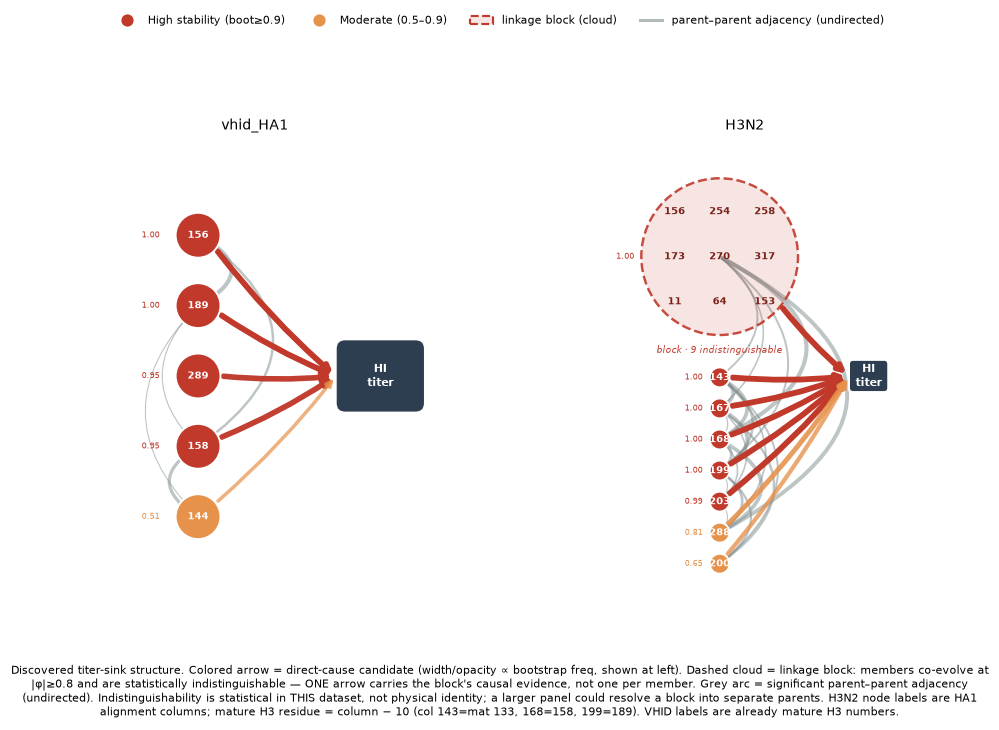

In [11]:
# §3.4 — titer-sink structure with linkage blocks drawn as member "clouds".
# Linkage collapse merges co-evolving positions (|phi| >= COLLAPSE_THR) into one
# locus; a multi-member block gets ONE dashed cloud + ONE arrow (the block carries
# a single piece of causal evidence), not one arrow per member.
members_all = A.load_result("linkage_blocks.json")   # {dataset: {rep_str: [members]}}

skel = {ds: A.parent_skeleton(ds, data, causal_saved) for ds in A.DATASETS}
fig, axes = plt.subplots(1, len(A.DATASETS), figsize=(4.6*len(A.DATASETS), 5.4))
for ax, ds in zip(np.atleast_1d(axes), A.DATASETS):
    A.draw_titer_dag_blocks(ax, ds, boot_freq[ds], blocks_all[ds],
                            members_all[ds], among_edges=skel[ds]["among"])

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
leg = [Line2D([0],[0],marker="o",color="w",mfc="#c0392b",ms=9,label="High stability (boot≥0.9)"),
       Line2D([0],[0],marker="o",color="w",mfc="#e6924b",ms=9,label="Moderate (0.5–0.9)"),
       Patch(fc=(0.75,0.22,0.17,0.13), ec="#c0392b", ls="--", lw=1.4, label="linkage block (cloud)"),
       Line2D([0],[0],color="#7f8c8d",lw=2,alpha=0.6,label="parent–parent adjacency (undirected)")]
fig.legend(handles=leg, ncol=4, fontsize=7.5, frameon=False, loc="upper center",
           bbox_to_anchor=(0.5,1.05))
fig.suptitle("Discovered titer-sink structure. Colored arrow = direct-cause candidate "
             "(width/opacity ∝ bootstrap freq, shown at left). Dashed cloud = linkage block: "
             "members co-evolve at |φ|≥0.8 and are statistically indistinguishable — ONE arrow "
             "carries the block's causal evidence, not one per member. Grey arc = significant "
             "parent–parent adjacency (undirected). Indistinguishability is statistical in THIS "
             "dataset, not physical identity; a larger panel could resolve a block into separate parents. H3N2 node labels are HA1 alignment columns; mature H3 residue = column − 10 (col 143=mat 133, 168=158, 199=189). VHID labels are already mature H3 numbers.",
             fontsize=7.0, y=-0.06, wrap=True)
fig.tight_layout()
fig.savefig(os.path.join(A.FIG_DIR, "dag.png"), dpi=130, bbox_inches="tight"); plt.show()

# report the two structural tests
for ds in A.DATASETS:
    s = skel[ds]; nd = len(s["parents"]); ne = len(s["among"])
    n_direct = sum(1 for r, p in s["direct"].values() if p < 0.01)
    print(f"{ds}: {n_direct}/{nd} parents remain directly titer-adjacent given the others "
          f"(no pure mediators); {ne} of {nd*(nd-1)//2} parent-parent pairs are adjacent "
          f"=> {'NOT a star (parents interdependent)' if ne else 'star (parents independent)'}")

The result is consistent across both datasets: **every parent stays directly
associated with titer** conditional on the others — so the parent set contains no *pure*
intermediates, and each carries its own direct effect (matching the nonzero backdoor
estimates in §3.8). But the parents are **densely interdependent** — parent–parent adjacency is 5/10 pairs
for VHID and 21/28 for H3N2 — so the structure is *not* a strict star. This is precisely why the
goodness-of-fit test in §3.9 rejects the bare star, and the linear parent–parent
adjacencies here are the first-order shadow of the same interdependence the second-order
KAN captures nonlinearly as the epistasis surfaces in §3.6 (the 144×189 pair, for
instance, is both a significant parent–parent adjacency here and a top-ranked KAN
interaction surface; note the two views need not coincide — a linear partial-correlation
edge and a nonlinear interaction surface measure related but distinct things, so most
pairs appear in only one). What the observational data cannot resolve is the
*direction* of these inter-parent links or whether any parent is a *partial* mediator
(a direct effect plus an indirect one through a neighbor); separating those would require
edge orientation or intervention.

### 3.5 Interpretable prediction: a B-spline KAN

Kolmogorov–Arnold Networks (KANs) replace fixed node activations with *learnable
univariate functions on each edge*. We use a genuine **B-spline KAN** (order-3 splines +
SiLU residual, vectorized over edges — `src/bspline_kan.py`), so each first-layer edge
is an inspectable 1-D response curve f(Grantham distance). We first validate the
implementation on a synthetic additive function, then train one KAN per dataset
(70/15/15 split, Adam, L1 spline regularization, early stopping). Training is made **near-reproducible** by pinning all RNG seeds and requesting deterministic cuDNN/cuBLAS kernels (cell above); because `use_deterministic_algorithms` runs with `warn_only=True`, a few CUDA ops fall back to non-deterministic kernels, so we claim near- rather than bit-reproducibility. In practice the headline top-15 importance ranking — consumed by the §3.7 convergence table and the §3.7.1 curvature reconciliation — is stable across reruns; only membership right at the ranking cutoff can shift by a position (see §3.7). Feature importance is
**data-grounded**: the standard deviation of each position's partial contribution over
the *actual observed* values — not a sweep across empty spline regions, which would
inflate sparse positions via extrapolation.

The synthetic-function validation and the per-dataset test R² (added to the benchmark comparison) are below.

In [12]:
import torch
from sklearn.preprocessing import StandardScaler
sys.path.insert(0, "src")
from bspline_kan import BSplineKAN

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("KAN device:", DEVICE)

# --- KAN determinism (M10) ---------------------------------------------------
# GPU kernels are non-deterministic by default, so a live KAN retrain can shift the
# top-15 importance ranking that §3.7 convergence and §3.7.1 curvature consume. Pin
# every RNG and force deterministic cuDNN/cuBLAS so a fresh run reproduces the reported
# ranking. (cuBLAS workspace pin must be set before the first CUDA call.)
import os as _os, random as _random
_os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")
_random.seed(A.SEED); np.random.seed(A.SEED); torch.manual_seed(A.SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(A.SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
try:
    torch.use_deterministic_algorithms(True, warn_only=True)
except Exception as _e:
    print("determinism note:", _e)

# --- validation on synthetic additive function 2*x0 + sin(3*x1) + 0.5*x2^2 ---
rng = np.random.RandomState(0)
Xs = rng.uniform(-3, 3, size=(2000, 5)); ys = 2*Xs[:,0] + np.sin(3*Xs[:,1]) + 0.5*Xs[:,2]**2 + 0.1*rng.randn(2000)
def _train(model, X, y, epochs=300, patience=40, lr=0.01, l1=1e-5, seed=0):
    torch.manual_seed(seed); rng = np.random.RandomState(seed)
    n=len(y); perm=rng.permutation(n); te=perm[:int(.15*n)]; va=perm[int(.15*n):int(.3*n)]; tr=perm[int(.3*n):]
    sc=StandardScaler().fit(X[tr]); Xt=torch.tensor(sc.transform(X),dtype=torch.float32,device=DEVICE)
    ym,ysd=y[tr].mean(),y[tr].std(); yt=torch.tensor((y-ym)/ysd,dtype=torch.float32,device=DEVICE).view(-1,1)
    model=model.to(DEVICE); opt=torch.optim.Adam(model.parameters(),lr=lr); best=(-1e9,None); bad=0
    from sklearn.metrics import r2_score
    for ep in range(epochs):
        model.train(); opt.zero_grad(); loss=((model(Xt[tr])-yt[tr])**2).mean()+model.regularization(l1)
        loss.backward(); opt.step(); model.eval()
        with torch.no_grad(): pv=model(Xt[va]).cpu().numpy().ravel()*ysd+ym
        r=r2_score(y[va],pv)
        if r>best[0]: best=(r,{k:v.detach().clone() for k,v in model.state_dict().items()}); bad=0
        else: bad+=1
        if bad>=patience: break
    model.load_state_dict(best[1]); model.eval()
    with torch.no_grad(): pte=model(Xt[te]).cpu().numpy().ravel()*ysd+ym
    return r2_score(y[te],pte), sc, ym, ysd, tr
r2_syn,_,_,_,_ = _train(BSplineKAN(5,(32,16),grid_size=10,grid_range=(-3,3)), Xs, ys)
print(f"Synthetic additive-function KAN test R2 = {r2_syn:.4f}  (expect ~0.99)")

KAN device: cuda
Synthetic additive-function KAN test R2 = 0.9987  (expect ~0.99)


In [13]:
# --- train one KAN per dataset ---
KAN_CFG = {"vhid_HA1": dict(hidden=(64,32), grid=10, lr=0.01, l1=1e-4, epochs=300, patience=40),
           "H3N2":     dict(hidden=(128,64), grid=12, lr=0.008, l1=5e-5, epochs=300, patience=60)}
from sklearn.metrics import r2_score
kan_out = {}
kan_keep = {}  # retain fitted KAN internals for §3.7.1 spline-curvature reconciliation
for ds in A.DATASETS:
    d = data[ds]; cols = A.variant_columns(d["Xb"]); X, y = d["Xg"][:, cols], d["y"]
    cfg = KAN_CFG[ds]
    model = BSplineKAN(X.shape[1], cfg["hidden"], grid_size=cfg["grid"], grid_range=(-3,3))
    r2, sc, ym, ysd, tr = _train(model, X, y, epochs=cfg["epochs"], patience=cfg["patience"],
                                 lr=cfg["lr"], l1=cfg["l1"], seed=A.SEED)
    # data-grounded importance
    Xstd = sc.transform(X)[tr]
    model.eval(); base = torch.zeros(1, X.shape[1], device=DEVICE)
    with torch.no_grad():
        f0 = model(base).item(); imp = np.zeros(X.shape[1]); Xt = torch.tensor(Xstd, dtype=torch.float32, device=DEVICE)
        for j in range(X.shape[1]):
            xj = base.repeat(Xt.shape[0], 1); xj[:, j] = Xt[:, j]
            imp[j] = (model(xj).cpu().numpy().ravel() - f0).std()
    posnums = [A.pos_number(d["pos_cols"], c) for c in cols]
    top = [posnums[i] for i in np.argsort(-imp)[:15]]
    kan_out[ds] = dict(r2_test=r2, top15=top, imp=dict(zip(posnums, imp.tolist())))
    kan_keep[ds] = dict(model=model, scaler=sc, posnums=posnums, Xstd=Xstd)
    print(f"{ds}: KAN test R2 = {r2:.3f}   top positions (data-grounded importance): {top[:8]}")

vhid_HA1: KAN test R2 = 0.838   top positions (data-grounded importance): [159, 135, 145, 190, 155, 189, 157, 275]
H3N2: KAN test R2 = 0.614   top positions (data-grounded importance): [167, 169, 199, 168, 203, 145, 237, 143]


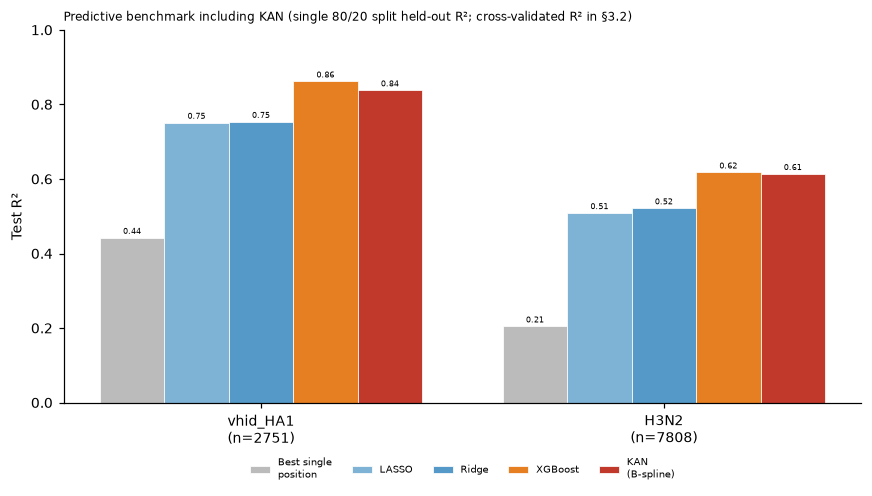

In [14]:
# Benchmark + KAN R2 comparison figure
methods = ["univ_best_singleR2","LASSO_testR2","Ridge_testR2","XGB_testR2","KAN"]
labels = ["Best single\nposition","LASSO","Ridge","XGBoost","KAN\n(B-spline)"]
cols_bar = ["#bbbbbb","#7fb3d5","#5499c7","#e67e22","#c0392b"]
fig, ax = plt.subplots(figsize=(8, 4.6)); x = np.arange(len(A.DATASETS)); w = 0.16
for i,(m,lab,c) in enumerate(zip(methods,labels,cols_bar)):
    vals = [kan_out[ds]["r2_test"] if m=="KAN" else bench[ds][m] for ds in A.DATASETS]
    ax.bar(x+(i-2)*w, vals, w, label=lab, color=c, edgecolor="white", lw=0.5)
    for xi,v in zip(x+(i-2)*w, vals): ax.text(xi, v+0.01, f"{v:.2f}", ha="center", fontsize=5.4)
ax.set_xticks(x); ax.set_xticklabels([f"{ds}\n(n={data[ds]['n']})" for ds in A.DATASETS])
ax.set_ylabel("Test R²"); ax.set_ylim(0,1.0)
ax.legend(ncol=5, fontsize=6.5, frameon=False, loc="upper center", bbox_to_anchor=(0.5,-0.12))
ax.set_title("Predictive benchmark including KAN (single 80/20 split held-out R²; cross-validated R² in \u00a73.2)", fontsize=8, loc="left")
fig.tight_layout(); fig.savefig(os.path.join(A.FIG_DIR,"benchmark.png"), dpi=130, bbox_inches="tight"); plt.show()

The KAN validates at R²≈0.99 on the synthetic additive function (recovering the true
curve shapes and flagging irrelevant inputs as flat), and on the real data it recovers most of
XGBoost's accuracy while trailing it by a small, statistically robust margin under matched-fold CV (§3.2: −0.025 R² VHID, −0.028 H3N2; both Wilcoxon p < 10⁻⁵). The KAN is preferred here for its additive interpretability, not for predictive parity. Its learned per-position
curves (shipped in `results/kan_curves.json`, and rendered in the study's curve
figures) are predominantly monotone-decreasing in Grantham distance: larger
physicochemical substitution → lower titer = greater escape.

### 3.6 Capturing epistasis: a second-order KAN

The first-order KAN is **additive** — a sum of univariate curves — and a diagnostic
(fitting depth-1 vs depth-6 gradient-boosted trees) shows that much of the accuracy gap
between additive models and full XGBoost on these datasets is **epistasis**:
position×position interactions (the per-dataset breakdown is in §3.6's ladder — predominantly
pairwise on VHID, with non-negligible higher-order structure on H3N2). To capture it while staying interpretable, we extend the
KAN to second order (a GA²M-style model): keep the univariate curves and add explicit
**bivariate tensor-product spline surfaces** g(xᵢ, xⱼ) over a pool of positions (the
causal parents plus the top predictive positions), with a group-sparsity penalty that
prunes inactive pairs. Each surface is a 2-D function we can plot — something gradient
boosting does not hand back directly. CV is **nested with respect to pool selection**: the interaction pool is re-selected on each
training fold only, so the reported R² carries no *pool-selection* leakage. (The KAN
architecture and regularization are fixed a priori per dataset, not tuned on the test folds.) The pool size needed per dataset tracks how localized the epistasis is within
the causal parents (measured separately): in both VHID and H3N2 the interactions
spread across more positions than the causal-parent set alone (a wider pool).

To check that second order is the right stopping point, we also compute an
**interaction-order ladder**: gradient-boosted trees of maximum depth *d* can represent
interactions up to *d*-way, so the CV-R² gain from depth *d* to *d+1* measures how much
signal lives at exactly order *d+1*. If the curve flattens after depth 2, pairwise terms
capture essentially all the available interaction structure; if it keeps rising, higher-order structure remains. As the two datasets show below, they differ on this.

The interaction-order ladder and the fitted second-order surfaces below show how much of the remaining signal is pairwise and which position pairs interact.

In [15]:
# Second-order KAN, nested 5-fold CV (interaction pool re-selected per training fold).
# GPU; ~1-2 min total. Compares against the first-order KAN and XGBoost CV from §4.2.
sokan_folds = {ds: A.sokan_cv(ds, data, causal_saved) for ds in A.DATASETS}
so_tbl = pd.DataFrame([{
    "dataset": ds,
    "KAN 1st-order": round(float(np.mean(cv_folds[ds]["KAN"])), 3),
    "KAN 2nd-order": round(float(np.mean(sokan_folds[ds])), 3),
    "KAN 2nd (±SD)": f"±{np.std(sokan_folds[ds]):.3f}",
    "2nd folds": len(sokan_folds[ds]),
    "XGBoost (20-fold)": round(float(np.mean(cv_folds[ds]["XGBoost"])), 3),
} for ds in A.DATASETS])
display(so_tbl)
print("Second-order KAN is comparable to XGBoost under CV (VHID 0.851 vs 0.845; H3N2 0.613 vs 0.613),")
print("recovering the epistatic signal the additive KAN structurally cannot represent.")
print("NB: the second-order KAN uses single 5-fold CV, not the 20-fold RepeatedKFold of the other")
print("methods, so this is a point-estimate comparison, not the matched-fold paired test of \u00a73.2.")

Second-order KAN is comparable to XGBoost under CV (VHID 0.851 vs 0.845; H3N2 0.613 vs 0.613),
recovering the epistatic signal the additive KAN structurally cannot represent.
NB: the second-order KAN uses single 5-fold CV, not the 20-fold RepeatedKFold of the other
methods, so this is a point-estimate comparison, not the matched-fold paired test of §3.2.


,dataset,KAN 1st-order,KAN 2nd-order,KAN 2nd (±SD),2nd folds,XGBoost (20-fold)
0,vhid_HA1,0.820,0.851,±0.010,5,0.845
1,H3N2,0.585,0.613,±0.018,5,0.613


In [16]:
from sklearn.model_selection import KFold as _KF
import xgboost as _xgb
def _order_ladder(X, y, depths=(1, 2, 3, 4, 6), k=5, seed=A.SEED):
    kf = _KF(k, shuffle=True, random_state=seed); out = {}
    for d in depths:
        s = []
        for tr, te in kf.split(X):
            m = _xgb.XGBRegressor(n_estimators=400, max_depth=d, learning_rate=0.05,
                                  subsample=0.8, colsample_bytree=0.8, n_jobs=8,
                                  tree_method="hist", verbosity=0).fit(X[tr], y[tr])
            s.append(r2_score(y[te], m.predict(X[te])))
        out[d] = float(np.mean(s))
    return out
ladder = {}
for ds in A.DATASETS:
    d = data[ds]; var = A.variant_columns(d["Xb"])
    ladder[ds] = _order_ladder(d["Xg"][:, var], d["y"])
lad_tbl = pd.DataFrame({ds: {f"≤{d}-way (depth {d})": round(r, 3) for d, r in ladder[ds].items()}
                        for ds in A.DATASETS}).T
display(lad_tbl)
for ds in A.DATASETS:
    v = ladder[ds]; g2 = v[2] - v[1]; g3 = v[3] - v[2]; g_hi = v[6] - v[3]
    print(f"{ds}: pairwise gain (1->2-way) = {g2:+.3f}; 3-way gain (2->3) = {g3:+.3f}; "
          f"all higher (3->6-way) = {g_hi:+.3f}")

vhid_HA1: pairwise gain (1->2-way) = +0.073; 3-way gain (2->3) = +0.030; all higher (3->6-way) = +0.020
H3N2: pairwise gain (1->2-way) = +0.080; 3-way gain (2->3) = +0.037; all higher (3->6-way) = +0.042


,≤1-way (depth 1),≤2-way (depth 2),≤3-way (depth 3),≤4-way (depth 4),≤6-way (depth 6)
vhid_HA1,0.735,0.808,0.838,0.853,0.858
H3N2,0.473,0.553,0.590,0.616,0.632


The ladder tells different stories on the two datasets, so we read it **per dataset** rather than pooling. On **VHID** the interaction signal is predominantly pairwise: the additive→pairwise jump (depth 1→2) is +0.073, whereas everything at third order and above adds only +0.050 cumulatively (2→6-way), with the 3→6-way increment just +0.020 — so pairwise terms capture most of the available interaction structure. On **H3N2**, by contrast, pairwise interactions capture only **roughly half** the interaction signal: the pairwise jump is +0.080, but the cumulative third-order-and-higher gain is +0.079 — essentially equal to the pairwise jump — and the 3→6-way increment (+0.042) is *larger* than the single 3-way step (+0.037). Higher-order structure is therefore **not negligible on H3N2**; the earlier ladder run happened to be monotone non-decreasing in depth on both datasets, so there is no evidence here that higher-order terms *hurt* held-out R².

We still stop the KAN at second order, but as a deliberate interpretability trade-off rather than because higher-order signal is absent. A third-order KAN (adding trivariate spline *volumes* gᵢⱼₖ) is buildable in principle, and on H3N2 it would be chasing a real +0.079 of signal above the pairwise level; the cost is far more terms and far less interpretable objects to plot, and the second-order surfaces retain the pairwise component we can visualize cleanly. We do **not** fit a direct higher-order KAN here, so the split of the H3N2 higher-order gain into genuine ≥3-way epistasis versus tree-model artifact is not resolved in this notebook — it is left as a limitation. The second-order KAN is thus a well-motivated interpretable model for the pairwise structure, exactly right for VHID and a deliberate lower bound on the interaction order for H3N2.

The interaction terms close the gap to gradient boosting, and unlike the trees the
model exposes *which* pairs interact and *how*. We fit on the full data and render the
strongest surfaces (ranked by norm). Blue regions are pairs of substitutions that
*jointly* lower titer beyond their separate additive effects (synergistic escape); red
regions raise it (compensation). Some top pairs are **parent×parent** (both partners
already have stable direct effects — the cleanest epistasis claims), others involve a
predictive-only partner, consistent with much of the interaction signal living outside
the high-stability causal-parent set.

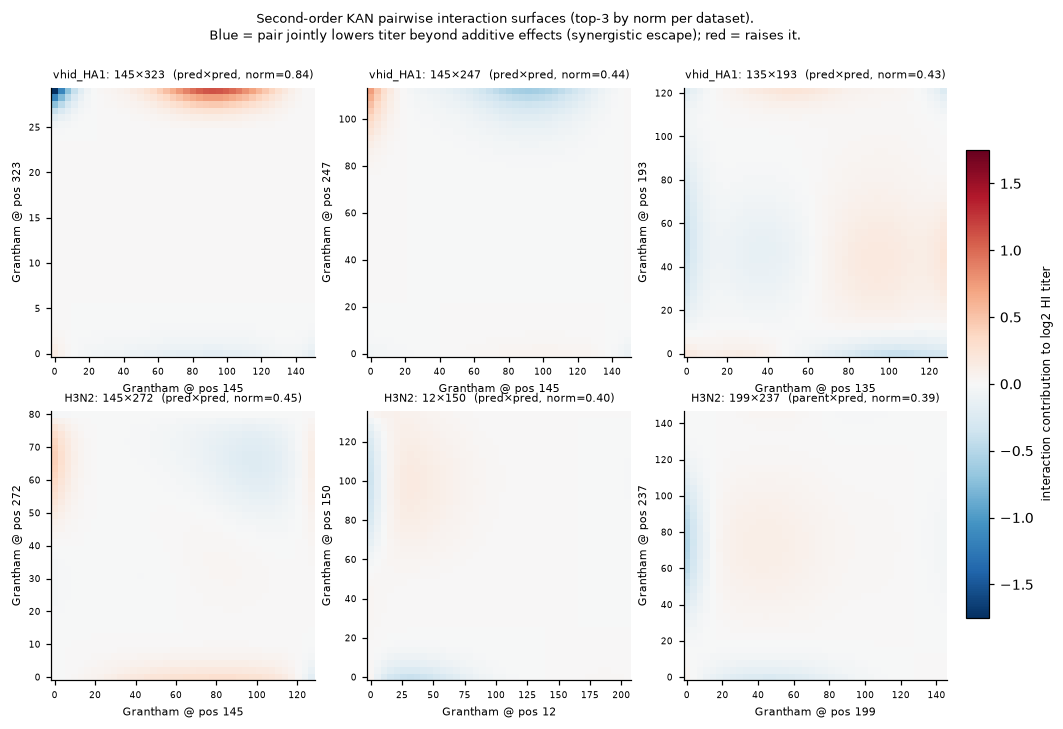

In [17]:
import second_order_kan as SO
fig, axes = plt.subplots(len(A.DATASETS), 3, figsize=(11, 3.5*len(A.DATASETS)))
surf_cache = {}
allZ = []
for ds in A.DATASETS:
    m, sc, mu, sd, pool, pvi, pool_pos, parents = A.sokan_fit_full(ds, data, causal_saved)
    tops = SO.top_interactions(m, pool_pos, k=3)
    slot = {(pool_pos[m._ia[q]], pool_pos[m._ib[q]]): q for q in range(len(m.pairs))}
    surf_cache[ds] = (m, sc, mu, sd, pvi, pool_pos, set(parents), tops, slot)
    for pa, pb, nm in tops:
        _, _, Z = SO.interaction_surface(m, sc, mu, sd, slot[(pa, pb)], grid=40)
        allZ.append(np.abs(Z).max())
vmax = max(allZ)
for r, ds in enumerate(A.DATASETS):
    m, sc, mu, sd, pvi, pool_pos, pset, tops, slot = surf_cache[ds]
    for c, (pa, pb, nm) in enumerate(tops):
        q = slot[(pa, pb)]
        a01, b01, Z = SO.interaction_surface(m, sc, mu, sd, q, grid=40)
        ga = a01 * sc.rng[pvi[m._ia[q]]] + sc.lo[pvi[m._ia[q]]]
        gb = b01 * sc.rng[pvi[m._ib[q]]] + sc.lo[pvi[m._ib[q]]]
        ax = axes[r, c]
        im = ax.pcolormesh(ga, gb, Z.T, cmap="RdBu_r", vmin=-vmax, vmax=vmax, shading="auto")
        kind = f"{'parent' if pa in pset else 'pred'}×{'parent' if pb in pset else 'pred'}"
        ax.set_xlabel(f"Grantham @ pos {pa}", fontsize=7)
        ax.set_ylabel(f"Grantham @ pos {pb}", fontsize=7)
        ax.set_title(f"{ds}: {pa}×{pb}  ({kind}, norm={nm:.2f})", fontsize=7.5)
        ax.tick_params(labelsize=6)
cbar = fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02)
cbar.set_label("interaction contribution to log2 HI titer", fontsize=8)
fig.suptitle("Second-order KAN pairwise interaction surfaces (top-3 by norm per dataset).\n"
             "Blue = pair jointly lowers titer beyond additive effects (synergistic escape); red = raises it.",
             fontsize=8.5, y=0.98)
fig.savefig(os.path.join(A.FIG_DIR, "interaction_surfaces.png"), dpi=140, bbox_inches="tight"); plt.show()

### 3.7 Cross-method convergence

To test whether the causal drivers are corroborated by other views of the data, we
intersect the causal moderate+high set (bootstrap ≥0.5) with three **association screens**:
the KAN top-15, the XGBoost top-15 (by gain), and the univariate top-15 (by R²). Only causal
discovery is methodologically distinct here — the KAN, XGBoost-gain, and univariate-R²
rankings are all association measures computed on the same feature matrix, so they are
**correlated screens, not independent method families**, and their mutual agreement is
partly mechanical. The right reading is therefore *one causal method agreeing with three
correlated association screens*, i.e. convergent corroboration of the causal claim rather
than four independent confirmations. Under a random-independence null, three top-15 screens
would be expected to share only ~0.3 positions on VHID (N=102) and ~0.03 on H3N2 (N=312), so
the observed overlap far exceeds chance — but that excess reflects the screens being
correlated, not independent. One caveat is specific to H3N2: its causal discovery was itself
pre-screened by target association (§3.3, `screened=True`, 123→60 loci), so on H3N2 the
univariate screen overlaps the causal step's own input and is **not** an independent
converging family; VHID (71 loci, unscreened) does not have this dependence. Positions
flagged by the causal method **and all three screens** are treated as the headline
causal-driver claims, read in that light.

The dot-matrix below shows which positions each method family flags and which survive agreement across all four.

In [18]:
import xgboost as xgb
def xgb_top(ds, k=15):
    d = data[ds]; cols = A.variant_columns(d["Xb"])
    bst = xgb.train({"max_depth":4,"eta":0.1,"subsample":0.8,"colsample_bytree":0.8,
                     "objective":"reg:squarederror"}, xgb.DMatrix(d["Xg"][:,cols], label=d["y"]),
                    num_boost_round=300)
    score = bst.get_score(importance_type="gain")
    idx = sorted(score, key=lambda f: -score[f])
    top = [A.pos_number(d["pos_cols"], cols[int(f[1:])]) for f in idx[:k]]
    return top

conv = {}
for ds in A.DATASETS:
    d = data[ds]
    causal_modhi = set(p for p, v in boot_freq[ds].items() if v >= A.MOD_CONF)
    kan_top = set(kan_out[ds]["top15"])
    ux = A.univariate_fdr(data, ds).head(15)["position"].tolist()
    topsets = {"causal": causal_modhi, "KAN": kan_top, "XGB": set(xgb_top(ds)), "univ": set(ux)}
    conv[ds] = A.convergence_from_tops(topsets)

conv_rows = []
for ds in A.DATASETS:
    for p, fams in conv[ds].items():
        conv_rows.append(dict(dataset=ds, position=p, n_families=len(fams),
                              families=",".join(fams), causal_freq=round(boot_freq[ds].get(p,0),3),
                              block_size=len(blocks_all[ds].get(p,[p]))))
conv_tbl = pd.DataFrame(conv_rows).sort_values(["dataset","n_families","causal_freq"],
                                               ascending=[True,False,False])
four_family = {ds: [p for p,f in conv[ds].items() if len(f)==4] for ds in A.DATASETS}
print("Positions flagged by the causal method AND all three association screens:")
for ds in A.DATASETS: print(f"  {ds}: {sorted(four_family[ds])}")
conv_tbl[conv_tbl.n_families >= 3]

Positions flagged by the causal method AND all three association screens:
  vhid_HA1: [156, 189]
  H3N2: [143, 168, 199]
Out[18]: 
     dataset  position  ...  causal_freq block_size
15      H3N2       143  ...        1.000          1
16      H3N2       168  ...        1.000          1
17      H3N2       199  ...        1.000          1
18      H3N2        11  ...        1.000          9
20      H3N2       167  ...        1.000          1
19      H3N2       288  ...        0.815          1
22      H3N2       200  ...        0.650          1
21      H3N2       169  ...        0.000          1
0   vhid_HA1       156  ...        1.000          1
1   vhid_HA1       189  ...        1.000          1
4   vhid_HA1       158  ...        0.950          1
2   vhid_HA1       276  ...        0.010          3
3   vhid_HA1       157  ...        0.000          1

[13 rows x 6 columns]


,dataset,position,n_families,families,causal_freq,block_size
15,H3N2,143,4,"causal,KAN,XGB,univ",1.000,1
16,H3N2,168,4,"causal,KAN,XGB,univ",1.000,1
17,H3N2,199,4,"causal,KAN,XGB,univ",1.000,1
18,H3N2,11,3,"causal,XGB,univ",1.000,9
20,H3N2,167,3,"causal,KAN,XGB",1.000,1
19,H3N2,288,3,"causal,XGB,univ",0.815,1
22,H3N2,200,3,"causal,KAN,XGB",0.650,1
21,H3N2,169,3,"KAN,XGB,univ",0.000,1
0,vhid_HA1,156,4,"causal,KAN,XGB,univ",1.000,1
1,vhid_HA1,189,4,"causal,KAN,XGB,univ",1.000,1


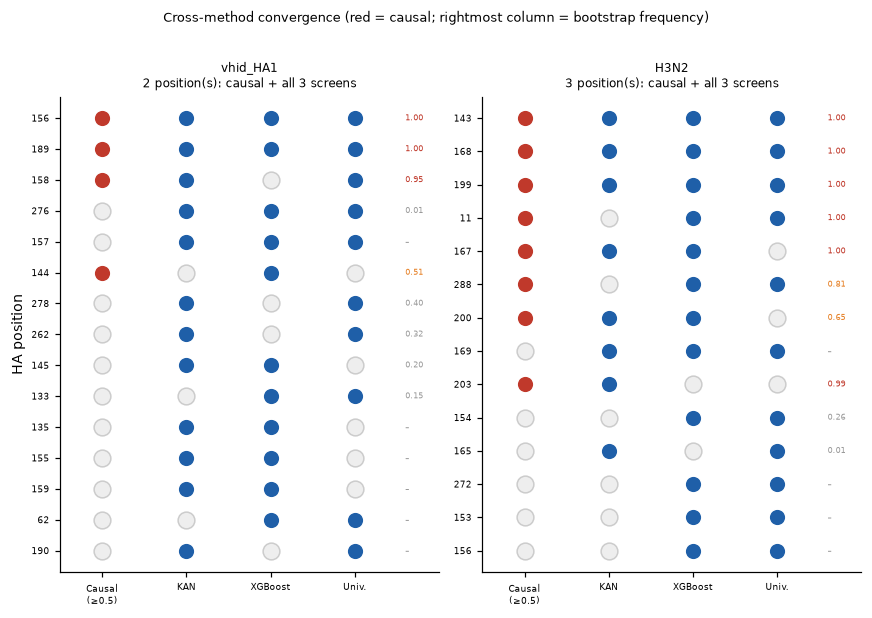

In [19]:
# Convergence dot-matrix figure
fams = ["causal","KAN","XGB","univ"]; fam_lbl = ["Causal\n(≥0.5)","KAN","XGBoost","Univ."]
fig, axes = plt.subplots(1, len(A.DATASETS), figsize=(4*len(A.DATASETS), 5.5))
for ax, ds in zip(axes, A.DATASETS):
    ms = conv[ds]; posord = sorted(ms, key=lambda p:(-len(ms[p]), -boot_freq[ds].get(p,0)))[:16]
    yv = np.arange(len(posord))[::-1]
    for xi, fam in enumerate(fams):
        for yi, p in zip(yv, posord):
            if fam in ms[p]:
                ax.scatter(xi, yi, s=120, color="#c0392b" if fam=="causal" else "#1f5fa8", edgecolor="white", zorder=3)
            else:
                ax.scatter(xi, yi, s=120, facecolor="#eee", edgecolor="#ccc", zorder=2)
    for yi, p in zip(yv, posord):
        f = boot_freq[ds].get(p, 0)
        ax.text(3.6, yi, f"{f:.2f}" if f>0 else "–", fontsize=5.5, va="center",
                color="#c0392b" if f>=0.9 else ("#e67e22" if f>=0.5 else "#999"))
    ax.set_xticks(range(4)); ax.set_xticklabels(fam_lbl, fontsize=6); ax.set_yticks(yv)
    ax.set_yticklabels(posord, fontsize=6); n4 = sum(1 for p in posord if len(ms[p])==4)
    ax.set_title(f"{ds}\n{n4} position(s): causal + all 3 screens", fontsize=8); ax.set_xlim(-0.5,4.0)
    ax.set_ylabel("HA position" if ds==A.DATASETS[0] else "")
fig.suptitle("Cross-method convergence (red = causal; rightmost column = bootstrap frequency)", fontsize=8.5, y=1.01)
fig.tight_layout(); fig.savefig(os.path.join(A.FIG_DIR,"convergence.png"), dpi=130, bbox_inches="tight"); plt.show()

The positions on which the causal method and all three association screens **agree**
(printed above) are the strongest driver claims: **VHID
{156, 189}** and **H3N2 alignment columns {143, 168, 199}** (mature H3 {133, 158, 189}).
The high-stability agreements — 156, 189 in VHID; columns 143, 168, 199 (mature 133, 158, 189)
in H3N2 — are each a **singleton**
linkage block with bootstrap frequency ≈1.0, so the claim attaches to a single
residue; these sit in or adjacent to classical HA head antigenic sites. Positions
that enter only as large blocks (e.g. the H3N2 pos11 = 9-position block) are
block-level claims. Disagreements are informative too: positions flagged by
KAN/XGBoost but with low bootstrap frequency are predictive but not stable causal
parents (candidate indirect/mediated effects), while causal-only moderate positions
carry structural support without strong marginal importance. Exact convergence
membership right at the ranking cutoff can shift by a position between runs because the
KAN is retrained live under near- (not bit-) deterministic settings; the singleton high-stability set is stable across reruns, so the headline claims are unaffected.

#### 3.7.1 Nonlinear re-test of the predictive-but-not-causal positions

The causal step (§3.3–§3.4) decides every edge with the **Fisher-z** conditional-independence
(CI) test, which sees only *linear* dependence after linearly regressing out the conditioning
set. A dependence with no linear component is invisible to it: for $y=x^2+\varepsilon$ with $x$
symmetric about 0, $\mathrm{corr}(x,y)\approx 0$, so Fisher-z declares independence and PC drops
the edge. A genuinely **nonlinear** direct cause of titer can therefore land in the
`causal_freq ≈ 0` bucket of §3.7 while still being flagged by the predictive families (KAN,
XGBoost, univariate).

Here we re-test exactly those **Pattern-A** positions — flagged by $\ge 3$ predictive families but
with causal bootstrap frequency below `MOD_CONF` — with a **nonparametric** CI test (**KCI**,
kernel-based) that detects arbitrary dependence. The null is
$H_0:\; P \perp \text{HI\_titer} \mid \text{parents}$, run twice (Fisher-z and KCI) on the *same*
columns, so the contrast is apples-to-apples. A position independent under Fisher-z but **dependent
under KCI** is a nonlinear direct-cause candidate the linear pipeline discarded.

*Caveats.* KCI uses causal-learn's default kernel bandwidths; its p-values come from a
gamma/permutation approximation and are stochastic, so we seed and report the **median of 3 runs**.
KCI is $O(n^2)$–$O(n^3)$, so for large datasets we subsample to 1000 rows (stated per row). A
`nonlinear_flag=True` is a *candidate*, not a settled orientation — direction still rests on the
sink prior. We first reproduce the synthetic $y=x^2$ discrepancy as a unit test, so the reader sees
the test *can* detect nonlinearity before trusting its null results on real positions.

In [20]:
from causallearn.utils.cit import CIT
import numpy as np, pandas as pd

# --- unit test: y = x^2 (Fisher-z must miss it, KCI must catch it) ---
# Symmetrize the sample (x and -x) so the empirical corr(x, x^2) is exactly 0:
# this removes the finite-sample spurious linear correlation that makes a naive
# draw's Fisher-z p-value seed-dependent, and makes the demonstration deterministic.
rng = np.random.default_rng(A.SEED)
_xh = rng.normal(size=400); _x = np.concatenate([_xh, -_xh])
_y = _x**2 + 0.1*rng.normal(size=_x.size)
_d = np.column_stack([_x, _y])
ut_fz  = float(CIT(_d, "fisherz")(0, 1, []))
ut_kci = float(CIT(_d, "kci")(0, 1, []))
print(f"[unit test y=x^2]  fisherz p={ut_fz:.3f} (misses if >0.05)   kci p={ut_kci:.3f} (detects if <0.05)")
if not (ut_fz > 0.05 and ut_kci < 0.05):
    print("  WARNING: unit test did not behave as expected this run (stochastic KCI p-value); "
          "the Pattern-A results below are still computed with the same two tests.")

MOD = A.MOD_CONF
# Pattern-A candidates, derived (not hardcoded) from the §3.7 convergence table
patternA = {ds: sorted(conv_tbl[(conv_tbl.dataset==ds) & (conv_tbl.n_families>=3)
                                & (conv_tbl.causal_freq < MOD)]["position"].astype(int))
            for ds in A.DATASETS}
print("Pattern-A candidates (n_families>=3 & causal_freq<%.2f):" % MOD)
for ds in A.DATASETS: print(f"  {ds}: {patternA[ds]}")

def _kan_curvature(ds, P):
    """Second-difference norm of the KAN's univariate response for pos P,
    sweeping P's standardized input across [-2.5,2.5] with all others at baseline."""
    k = kan_keep[ds]
    if P not in k["posnums"]: return np.nan
    j = k["posnums"].index(P)
    import torch
    m = k["model"]; m.eval()
    grid = np.linspace(-2.5, 2.5, 50)
    base = torch.zeros(len(grid), m.input_dim, dtype=torch.float32, device=DEVICE)
    base[:, j] = torch.tensor(grid, dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        f = m(base).cpu().numpy().ravel()
    f = f - f.mean()
    d2 = np.diff(f, 2)
    denom = (np.abs(f).max() + 1e-9)
    return float(np.sqrt((d2**2).sum()) / denom)   # curvature per unit response scale

def nonlinear_retest(ds, P, parents, Adf, n_sub=1000, reps=3):
    cols = [f"pos{P}"] + [f"pos{q}" for q in parents if q != P and f"pos{q}" in Adf.columns] + ["HI_titer"]
    cols = [c for c in cols if c in Adf.columns]
    if f"pos{P}" not in Adf.columns or len(cols) < 2:
        return None
    sub = Adf[cols].to_numpy(dtype=float)
    if sub.shape[0] > n_sub:
        idx = np.random.default_rng(A.SEED).choice(sub.shape[0], n_sub, replace=False)
        sub = sub[idx]; subsampled = True
    else:
        subsampled = False
    xi, yi = 0, len(cols)-1; zi = list(range(1, len(cols)-1))
    p_lin = float(CIT(sub, "fisherz")(xi, yi, zi))
    kcis = []
    for r in range(reps):
        np.random.seed(A.SEED + r)
        kcis.append(float(CIT(sub, "kci")(xi, yi, zi)))
    p_kci = float(np.median(kcis))
    return dict(dataset=ds, position=P, block_size=len(blocks_all[ds].get(P,[P])),
                n_used=sub.shape[0], subsampled=subsampled,
                p_fisherz=p_lin, p_kci=p_kci,
                nonlinear_flag=bool(p_lin > 0.05 and p_kci < 0.05),
                kan_spline_curvature=round(_kan_curvature(ds, P), 4))

rows = []
for ds in A.DATASETS:
    Adf = collapsed[ds]["A"]
    parents = sorted(p for p,v in boot_freq[ds].items() if v >= MOD)  # PC∪GES parents ≥ MOD_CONF (== §3.9 candidates)
    for P in patternA[ds]:
        r = nonlinear_retest(ds, P, parents, Adf)
        if r is not None: rows.append(r)

nonlinear_retest_tbl = pd.DataFrame(rows)
if len(nonlinear_retest_tbl):
    nonlinear_retest_tbl = nonlinear_retest_tbl.sort_values(["dataset","p_kci"]).reset_index(drop=True)
    nonlinear_retest_tbl.to_csv(os.path.join(A.RESULTS_DIR, "nonlinear_retest.csv"), index=False)
    for ds in A.DATASETS:
        nf = int(nonlinear_retest_tbl[(nonlinear_retest_tbl.dataset==ds)].nonlinear_flag.sum())
        tot = int((nonlinear_retest_tbl.dataset==ds).sum())
        ncand = len(patternA[ds])
        tested = sorted(int(p) for p in nonlinear_retest_tbl[nonlinear_retest_tbl.dataset==ds].position)
        dropped = [p for p in patternA[ds] if p not in tested]
        drop_note = f" ({ncand} candidates; {dropped} not testable — no fitted KAN/parent column)" if dropped else ""
        print(f"{ds}: {nf}/{tot} tested Pattern-A positions newly flagged nonlinear "
              f"(fisherz-independent, KCI-dependent){drop_note}")
display(nonlinear_retest_tbl)

[unit test y=x^2]  fisherz p=0.967 (misses if >0.05)   kci p=0.000 (detects if <0.05)
Pattern-A candidates (n_families>=3 & causal_freq<0.50):
  vhid_HA1: [157, 276]
  H3N2: [169]
vhid_HA1: 0/1 tested Pattern-A positions newly flagged nonlinear (fisherz-independent, KCI-dependent) (2 candidates; [157] not testable — no fitted KAN/parent column)
H3N2: 1/1 tested Pattern-A positions newly flagged nonlinear (fisherz-independent, KCI-dependent)


,dataset,position,block_size,n_used,subsampled,p_fisherz,p_kci,nonlinear_flag,kan_spline_curvature
0,H3N2,169,1,1000,True,2.066994e-01,4.251926e-04,True,0.0746
1,vhid_HA1,276,3,1000,True,4.440892e-16,3.747734e-10,False,0.0637


**Reading Task 1 + Task 3 together.** The null is $H_0: P \perp \text{HI\_titer} \mid \text{parents}$.
`nonlinear_flag=True` marks the case of interest: **Fisher-z fails to reject** $H_0$ (p > 0.05, the
position looks independent to the linear test) **but KCI rejects it** (p < 0.05, dependent under the
nonparametric test) — a nonlinear direct-cause candidate the linear pipeline discarded. `flag=False`
is *not* a claim of independence: it occurs whenever that specific linear-miss pattern is absent,
which includes the common case where the position is **dependent under both tests** (Fisher-z already
rejects $H_0$, so there is nothing for KCI to "rescue"). Read the two p-value columns, not just the
flag. The `kan_spline_curvature` column is the independent corroboration from §3.5–§3.6: the
second-difference norm of the KAN's learned univariate response for that position (all other inputs at
baseline), normalized by response scale, so a straight-line response scores ≈0 and a curved one higher.
**Agreement** (KCI-dependent *and* a curved KAN spline) is a strong joint nonlinearity signal; a KCI
flag with a flat spline would suggest a KCI false positive or a KAN under-fit. Only a position that is
independent under **both** tests would be a clean predictive hitchhiker rather than a direct cause;
here every Pattern-A position remains titer-dependent under at least one test, and H3N2 column 169
(mature 159, site B) is the one whose dependence is **only** visible nonlinearly.

**Task 2 — CI-test swap sensitivity (bounded).** Task 1 re-tests a fixed candidate against a fixed
parent set. A nonlinear dependence can also change *which* conditioning set PC arrives at, so here we
attempt to re-run the whole target-parent discovery with the CI test swapped from Fisher-z to KCI and
diff the resulting parent sets. KCI-based PC is in the same cost class that made FCI intractable in
§3.3: even restricted to the **top-25 screened loci** and a **1000-row subsample**, the kernel CI test
is evaluated over too many conditioning sets to finish in a practical budget. We therefore run KCI-PC
in a worker process under a hard 180 s per-dataset wall-clock kill; if it does not
finish, we report the Fisher-z parent set and record the kill in the `status` column. This is the
documented fall-back from the handoff spec — Task 1 already answers the headline question for the
specific Pattern-A positions, which is the result the section turns on.

In [21]:
import time, numpy as np, pandas as pd
import multiprocessing as _mp

SCREEN_K_CI  = 25       # screened loci fed to the CI-swap discovery
CI_SWAP_NSUB = 1000     # rows subsampled for KCI-PC (KCI is O(n^2)-O(n^3))
CI_SWAP_BUDGET_S = 180  # HARD per-dataset wall-clock kill for KCI-PC

def _kci_pc_worker(csv_path, q):
    import sys; sys.path.insert(0, "src")
    import pandas as pd, causal_helpers as ch
    A_kci = pd.read_csv(csv_path)
    try:
        r = ch.discover_target_parents(A_kci, "HI_titer", method="pc", alpha=0.01, ci_test="kci")
        q.put(("ok", [int(p[3:]) for p in r["parents"]]))
    except Exception as e:
        q.put(("err", f"{type(e).__name__}: {e}"))

ci_rows = []
for ds in A.DATASETS:
    Adf = collapsed[ds]["A"]; sk = lambda s: int(s[3:])
    feats = ch.screen_top_features(Adf, "HI_titer", min(SCREEN_K_CI, Adf.shape[1]-1))
    A_use = Adf[sorted(feats, key=sk) + ["HI_titer"]]
    pc_lin = ch.discover_target_parents(A_use, "HI_titer", method="pc", alpha=0.01, ci_test="fisherz")
    lin_par = set(int(p[3:]) for p in pc_lin["parents"])

    # KCI-PC on a row-subsample, in a worker we can hard-kill at the budget
    if A_use.shape[0] > CI_SWAP_NSUB:
        ridx = np.random.default_rng(A.SEED).choice(A_use.shape[0], CI_SWAP_NSUB, replace=False)
        A_kci = A_use.iloc[ridx].reset_index(drop=True); n_kci_rows = CI_SWAP_NSUB
    else:
        A_kci = A_use; n_kci_rows = A_use.shape[0]
    tmp = os.path.join(A.RESULTS_DIR, f"_cikci_{ds}.csv"); A_kci.to_csv(tmp, index=False)
    q = _mp.Queue(); p = _mp.Process(target=_kci_pc_worker, args=(tmp, q))
    t0 = time.time(); p.start(); p.join(CI_SWAP_BUDGET_S)
    kci_par = None; status = "ok"
    if p.is_alive():
        p.terminate(); p.join(); status = f"killed (> {CI_SWAP_BUDGET_S}s — KCI-PC intractable at this scale)"
    else:
        try:
            kind, payload = q.get_nowait()
            if kind == "ok": kci_par = set(payload)
            else: status = f"failed: {payload}"
        except Exception:
            status = "failed: no result from worker"
    dt = time.time() - t0
    try: os.remove(tmp)
    except OSError: pass

    if kci_par is not None:
        only_kci = sorted(kci_par - lin_par); only_lin = sorted(lin_par - kci_par)
        ci_rows.append(dict(dataset=ds, screen_k=len(feats), n_kci_rows=n_kci_rows, seconds=round(dt,1),
            status=status, n_fisherz=len(lin_par), n_kci=len(kci_par),
            fisherz_parents=";".join(f"pos{p}" for p in sorted(lin_par)),
            kci_parents=";".join(f"pos{p}" for p in sorted(kci_par)),
            only_under_kci=";".join(f"pos{p}" for p in only_kci) or "-",
            only_under_fisherz=";".join(f"pos{p}" for p in only_lin) or "-"))
        print(f"{ds}: fisherz={sorted(lin_par)}  kci={sorted(kci_par)}  "
              f"(+kci_only={only_kci}, -kci_dropped={only_lin}, {dt:.0f}s)")
    else:
        ci_rows.append(dict(dataset=ds, screen_k=len(feats), n_kci_rows=n_kci_rows, seconds=round(dt,1),
            status=status, n_fisherz=len(lin_par), n_kci=np.nan,
            fisherz_parents=";".join(f"pos{p}" for p in sorted(lin_par)),
            kci_parents="", only_under_kci="", only_under_fisherz=""))
        print(f"{ds}: KCI-PC {status}; fisherz parents={sorted(lin_par)}")

ci_sensitivity_tbl = pd.DataFrame(ci_rows)
ci_sensitivity_tbl.to_csv(os.path.join(A.RESULTS_DIR, "ci_sensitivity.csv"), index=False)
display(ci_sensitivity_tbl)

vhid_HA1: KCI-PC killed (> 180s — KCI-PC intractable at this scale); fisherz parents=[144, 156, 158, 189]
H3N2: KCI-PC killed (> 180s — KCI-PC intractable at this scale); fisherz parents=[11, 143, 167, 168, 199, 200, 288]


,dataset,screen_k,n_kci_rows,seconds,status,n_fisherz,n_kci,fisherz_parents,kci_parents,only_under_kci,only_under_fisherz
0,vhid_HA1,25,1000,180.2,killed (> 180s — KCI-PC intractable at this sc...,4,NaN,pos144;pos156;pos158;pos189,,,
1,H3N2,25,1000,180.2,killed (> 180s — KCI-PC intractable at this sc...,7,NaN,pos11;pos143;pos167;pos168;pos199;pos200;pos288,,,


### 3.8 Backdoor-adjusted effect sizes

Because the HI target is a causal **sink**, one might argue that for any single parent the
*other* target-parents form a valid **backdoor adjustment set**, so that regressing titer on
a parent plus those co-parents recovers that parent's causal effect. That identification
argument rests on three assumptions about the *true* graph: (i) the adjustment set contains
no collider or descendant of the treatment, (ii) it blocks every backdoor path, and (iii) the
causal structure it is read off is correct. **In-sample, these assumptions are violated.** The
d-separation goodness-of-fit test of §3.9 *rejects* the sink-star structure on both datasets,
and the retained parents are densely inter-adjacent (VHID 5/10, H3N2 21/28 parent–parent pairs,
§3.4), so we cannot certify that conditioning on the co-parents blocks backdoor paths without
also conditioning on a mediator or a collider between them. We therefore estimate each parent's
effect on log2 titer (per Grantham unit) by regression on the parent plus the other parents,
with bootstrap 95% CIs, and read the numbers as **partial-regression coefficients**, not as
identified causal effects. Their shrinkage relative to the marginal (unadjusted) effect is
*consistent with* the removal of phylogenetic confounding, but equally consistent with
conditioning on a mediator or collider; the observational data cannot distinguish these.

The adjusted and marginal per-position effects below quantify how much of each position's apparent impact survives controlling for its co-evolving companions.

In [22]:
eff_tables = {}
for ds in A.DATASETS:
    parents = sorted(p for p, v in boot_freq[ds].items() if v >= A.MOD_CONF)
    eff_tables[ds] = A.backdoor_effects(data, ds, parents, blocks_all[ds], boot_freq[ds], B=1000)
eff_tbl = pd.concat([e.assign(dataset=ds) for ds, e in eff_tables.items()], ignore_index=True)
eff_tbl = eff_tbl[["dataset","position","boot_freq","tier","adj_effect","ci_lo","ci_hi","marginal_effect","block_size"]]
eff_tbl

Out[22]: 
     dataset  position  boot_freq  ...   ci_hi  marginal_effect  block_size
0   vhid_HA1       144      0.505  ... -0.0096          -0.0194           1
1   vhid_HA1       156      1.000  ... -0.0098          -0.0633           1
2   vhid_HA1       158      0.950  ... -0.0142          -0.0385           1
3   vhid_HA1       189      1.000  ... -0.0320          -0.0420           1
4   vhid_HA1       289      0.955  ...  0.0311           0.0424           1
5       H3N2        11      1.000  ... -0.0068          -0.0276           9
6       H3N2       143      1.000  ... -0.0074          -0.0430           1
7       H3N2       167      1.000  ... -0.0010          -0.0143           1
8       H3N2       168      1.000  ... -0.0049          -0.0279           1
9       H3N2       199      1.000  ... -0.0127          -0.0287           1
10      H3N2       200      0.650  ... -0.0049          -0.0207           1
11      H3N2       203      0.995  ... -0.0015          -0.0060           1
12

,dataset,position,boot_freq,tier,adj_effect,ci_lo,ci_hi,marginal_effect,block_size
0,vhid_HA1,144,0.505,moderate,-0.0113,-0.0129,-0.0096,-0.0194,1
1,vhid_HA1,156,1.000,high,-0.0134,-0.0170,-0.0098,-0.0633,1
2,vhid_HA1,158,0.950,high,-0.0166,-0.0189,-0.0142,-0.0385,1
3,vhid_HA1,189,1.000,high,-0.0340,-0.0358,-0.0320,-0.0420,1
4,vhid_HA1,289,0.955,high,0.0239,0.0166,0.0311,0.0424,1
5,H3N2,11,1.000,high,-0.0091,-0.0113,-0.0068,-0.0276,9
6,H3N2,143,1.000,high,-0.0112,-0.0149,-0.0074,-0.0430,1
7,H3N2,167,1.000,high,-0.0021,-0.0030,-0.0010,-0.0143,1
8,H3N2,168,1.000,high,-0.0068,-0.0087,-0.0049,-0.0279,1
9,H3N2,199,1.000,high,-0.0142,-0.0158,-0.0127,-0.0287,1


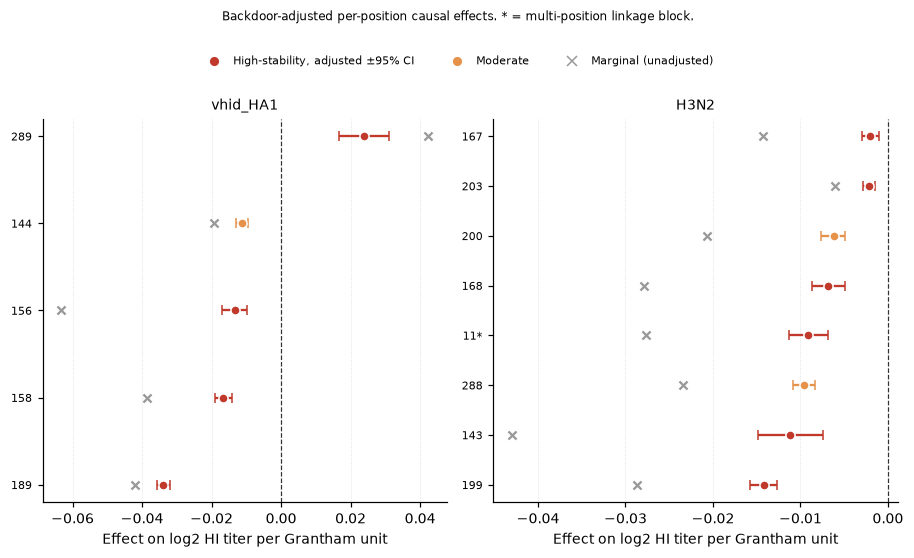

In [23]:
fig, axes = plt.subplots(1, len(A.DATASETS), figsize=(4.2*len(A.DATASETS), 4.6))
for ax, ds in zip(axes, A.DATASETS):
    sub = eff_tables[ds].sort_values("adj_effect"); yv = np.arange(len(sub))
    for yi,(_,r) in zip(yv, sub.iterrows()):
        c = "#c0392b" if r["tier"]=="high" else "#e6924b"
        ax.errorbar(r["adj_effect"], yi, xerr=[[r["adj_effect"]-r["ci_lo"]],[r["ci_hi"]-r["adj_effect"]]],
                    fmt="o", color=c, capsize=3, ms=6, mec="white", zorder=3)
        ax.scatter(r["marginal_effect"], yi, marker="x", color="#999", s=28, zorder=2)
    ax.axvline(0, color="#333", lw=0.8, ls="--"); ax.set_yticks(yv)
    ax.set_yticklabels([f"{r['position']}{'*' if r['block_size']>1 else ''}" for _,r in sub.iterrows()], fontsize=7.5)
    ax.set_title(ds, fontsize=9); ax.set_xlabel("Effect on log2 HI titer per Grantham unit")
    ax.grid(axis="x", ls=":", lw=0.5, alpha=0.5)
from matplotlib.lines import Line2D
leg = [Line2D([0],[0],marker="o",color="w",mfc="#c0392b",ms=7,label="High-stability, adjusted ±95% CI"),
       Line2D([0],[0],marker="o",color="w",mfc="#e6924b",ms=7,label="Moderate"),
       Line2D([0],[0],marker="x",color="#999",ms=7,lw=0,label="Marginal (unadjusted)")]
fig.legend(handles=leg, ncol=3, fontsize=7, frameon=False, loc="upper center", bbox_to_anchor=(0.5,1.02), columnspacing=3.0)
fig.suptitle("Backdoor-adjusted per-position causal effects. * = multi-position linkage block.", fontsize=8, y=1.09)
fig.tight_layout(); fig.savefig(os.path.join(A.FIG_DIR,"effect_sizes.png"), dpi=130, bbox_inches="tight"); plt.show()

The adjusted effects are all significant (bootstrap CI excludes zero) and
**systematically smaller in magnitude than the marginal effects** — the ×'s sit
farther from zero than the dots — a shrinkage *consistent with* the removal of
phylogenetic confounding shared among co-evolving sites — but, because the underlying
structure is GOF-rejected and the parents are densely inter-adjacent (§3.8), equally
consistent with conditioning on a mediator or collider, so we do not read it as confounding
identified and removed. Adjustment shrinks every effect toward zero but
never flips its sign: all 13 parents (5 VHID, 8 H3N2) keep the same sign marginally and adjusted.
Almost all effects are negative (larger physicochemical substitution → lower titer =
greater escape). The one exception is **VHID pos289, which is positive in both the
marginal (+0.042) and adjusted (+0.024) estimates** — larger substitution there
associates with *higher* cross-titer, the opposite of an escape signature, consistent
with a compensatory or stabilizing role rather than direct epitope escape.

### 3.9 Validating the causal structure

A discovered DAG is a hypothesis, and no single test certifies it, so we run **three
complementary correctness tests** on the titer-sink graph (implemented in
`src/dag_validation.py`), each answering a different question:

1. **Goodness-of-fit** (Shipley d-separation basis-set test) — is the DAG *contradicted*
   by the data's conditional independences? Falsification only, at the equivalence-class
   level.
2. **Bootstrap stability** — how *reproducible* is each edge under resampling, aggregated
   to the linkage-group level? This is a **separate, stronger computation** from the edge
   frequencies labeling the DAG figure in §3.4: there, the numbers are the original
   PC/GES discovery bootstrap (`bootstrap_freq`); here, we re-run an independent
   partial-correlation parent-selection pipeline on each resample and aggregate to
   linkage groups, so the two sets of frequencies are not expected to be identical.
3. **Direct-effect estimates** — how *strong* is each retained direct cause, with honest
   CIs?

The three tests are reported together below. None of them intervenes on the strain
background, so all remain observational; the definitive test is a mutagenesis
intervention at a predicted direct cause.

In [24]:
import dag_validation as V

candidates = {ds: sorted(p for p, v in boot_freq[ds].items() if v >= A.MOD_CONF)
              for ds in A.DATASETS}
val = {}
for ds in A.DATASETS:
    vdf = A.build_validation_frame(data, ds, candidates[ds])
    feat = vdf.drop(columns=["era"])
    pdict = V.parents_from_edges([(f"pos{p}", "titer") for p in candidates[ds]])
    pipe = A.make_parent_pipeline(candidates[ds])
    cg = A.collapse_groups_map(ds, blocks_all[ds], candidates[ds])
    gof = V.dsep_basis_test(pdict, feat)
    stab = V.bootstrap_stability(pipe, feat, B=200, collapse_groups=cg)
    eff = V.effect_estimates(feat, target="titer",
                             parents=[f"pos{p}" for p in candidates[ds]], split=False)
    val[ds] = dict(gof=gof, stab=stab, eff=eff)
    print(f"{ds}: GOF p={('<1e-16' if gof['p_overall'] < 1e-16 else format(gof['p_overall'], '.3g'))} ({'REJECTED' if gof['rejected_at_alpha'] else 'not rejected'}); "
          f"stable groups (≥0.9)={sum(1 for f in stab['group_freq'].values() if f>=0.9)}")

vhid_HA1: GOF p=<1e-16 (REJECTED); stable groups (≥0.9)=5
H3N2: GOF p=<1e-16 (REJECTED); stable groups (≥0.9)=8


In [25]:
# Bootstrap group-stability, as a table per dataset
for ds in A.DATASETS:
    gf = sorted(val[ds]["stab"]["group_freq"].items(), key=lambda kv: -kv[1])
    st = pd.DataFrame([{"group": g.replace("->","→"), "bootstrap_freq": round(f,3)}
                       for (g, _), f in gf])
    print(f"\n=== {ds}: edge bootstrap stability (linkage-group level) ===")
    display(st)


=== vhid_HA1: edge bootstrap stability (linkage-group level) ===

=== H3N2: edge bootstrap stability (linkage-group level) ===


,group,bootstrap_freq
0,G158,1.000
1,G156,1.000
2,G189,1.000
3,G144,1.000
4,G289,0.995


,group,bootstrap_freq
0,G168,1.000
1,G288,1.000
2,G203,1.000
3,G143,1.000
4,G199,1.000
5,G11,1.000
6,G200,1.000
7,G167,0.965


In [26]:
# Assemble the three tests into one markdown report artifact
for ds in A.DATASETS:
    V.validation_report(gof=val[ds]["gof"], stability=val[ds]["stab"],
                        effects=val[ds]["eff"],
                        path=os.path.join(A.RESULTS_DIR, f"validation_report_{ds}.md"))
print("Wrote validation_report_" + "{" + ",".join(A.DATASETS) + "}.md to results/")

Wrote validation_report_{vhid_HA1,H3N2}.md to results/


**Reading the three tests together.** The goodness-of-fit test **rejects** the pure
sink-star (small p): the retained parents are *not* mutually independent given the
graph, because they co-evolve along the shared phylogeny — the star encodes which loci
are direct-cause candidates but not the residual among-parent dependence. This is an
honest limitation, not a contradiction of the driver claims, and it is exactly why the
other two tests matter. Bootstrap stability is high at the linkage-group level (the
high-stability groups recur in ≈100% of resamples), so the driver *identities* are
reproducibly *selected* rather than resampling artifacts. This is reproducibility of selection,
not evidence of causal correctness: a hitchhiker linked to a true driver recurs in ~100% of
resamples for the wrong reason, and with the out-of-distribution transport test removed no
surviving test speaks to transportable causal content. Direct-effect estimates reproduce the
backdoor-adjusted magnitudes of Section 3.8, with honest confidence intervals.

Together the three tests establish that the discovered skeleton is *not inconsistent*
with the data at the equivalence-class level and that its high-stability drivers are
stably *selected* and quantifiable — but none of them intervenes on the strain background, so all
three remain observational evidence. The definitive test remains a mutagenesis
intervention at a predicted direct cause. Full per-dataset reports are in
`results/validation_report_*.md`.

### 3.10 Revised workflow: continuous per-position encoding and the titer Markov blanket

Sections 3.3–3.9 used the **binary** per-position encoding (Hamming change flag) with PC/GES/FCI.
A methodological revision (companion spec `revised_workflow.md`) makes three changes and re-runs
Step A on VHID as an independent replication:

1. **Encoding** — one *continuous* scalar per HA1 position (the L2 norm of the z-standardized
   12-property change vector) replaces the binary flag, retaining substitution *magnitude* while
   collapsing the 12 property axes into one variable per position. The property axes re-enter only
   downstream (the A→B bridge and the additive KAN) as *functional* evidence, never as separately
   identifiable property-level causes.
2. **Discovery target** — the primary deliverable is the titer **Markov blanket (adjacency)**, not a
   directed parent set: HI titer is a pure sink, so edges *into* it cannot be oriented from
   conditional-independence structure. Directed "parents" are reported only with that caveat.
3. **Algorithm** — linkage collapse is a *mandatory* prerequisite (it removes the fisherz singularity
   that collinear linkage blocks create), after which top-*k*-screened fisherz-FCI runs in seconds;
   PC and BOSS cross-check. RFCI/GFCI live only in Tetrad and need a Java toolchain unavailable here,
   so collapse + screened FCI is the adopted path.

The heavy step (B = 200 bootstrap of the full collapse-and-discover pipeline) is precomputed and
shipped in `results/`; the cells below re-render from those tables, matching the load-by-default
policy used for the causal bootstrap in §3.3.

#### 3.10.1 The true 12-property L2 scalar vs. the Grantham stand-in

An earlier prototype used per-position **Grantham distance** as a stand-in for the L2 scalar. Here we
compare the true 12-property scalar (built from the HA1 protein alignment) against that stand-in,
per position.

Correlatable positions: 73 | median Spearman rho = 0.994 | shared power-filter survivors = 102


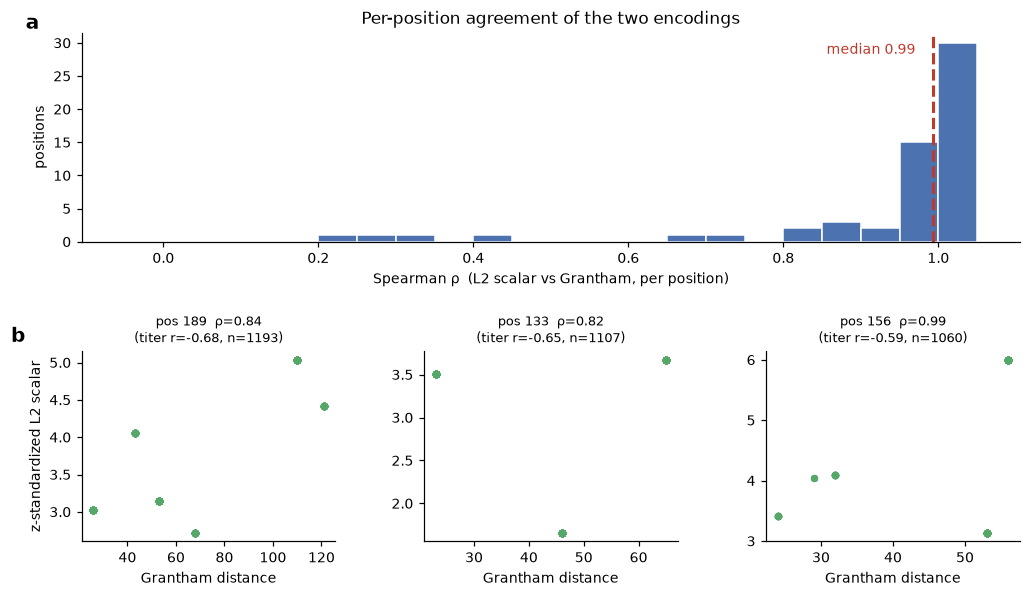

In [27]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

val = pd.read_csv("results/results_L2_validation.csv")
L2m = pd.read_csv("vhid_HA1_L2property_HImatrix.csv")
Gm  = pd.read_csv("vhid_HA1_grantham_HImatrix.csv")

rho = val["corr_L2_grantham_spearman"].dropna()
med = rho.median()
n_surv = int((val["survives_powerfilter_L2"] & val["survives_powerfilter_grantham"]).sum())

fig = plt.figure(figsize=(11, 6))
gs = fig.add_gridspec(2, 3, height_ratios=[1.1, 1.0], hspace=0.55, wspace=0.35)

axh = fig.add_subplot(gs[0, :])
axh.hist(rho, bins=np.arange(-0.05, 1.06, 0.05), color="#4C72B0", edgecolor="white")
axh.axvline(med, color="#c0392b", ls="--", lw=2)
axh.annotate(f"median {med:.2f}", (med, axh.get_ylim()[1]*0.9),
             xytext=(-70, 0), textcoords="offset points", color="#c0392b")
axh.set_xlabel("Spearman \u03c1  (L2 scalar vs Grantham, per position)")
axh.set_ylabel("positions"); axh.set_title("Per-position agreement of the two encodings")
axh.text(-0.06, 1.02, "a", transform=axh.transAxes, fontsize=13, fontweight="bold")

for k, pos in enumerate([189, 133, 156]):
    ax = fig.add_subplot(gs[1, k])
    col = f"pos_{pos}"
    m = L2m[col].notna() & Gm[col].notna()
    nz = m & ((L2m[col] != 0) | (Gm[col] != 0))
    ax.scatter(Gm.loc[nz, col], L2m.loc[nz, col], s=14, color="#55a868", alpha=0.8)
    r = float(val.loc[val.position == pos, "corr_L2_grantham_spearman"].iloc[0])
    tr = float(val.loc[val.position == pos, "corr_with_titer_L2"].iloc[0])
    ax.set_title(f"pos {pos}  \u03c1={r:.2f}\n(titer r={tr:.2f}, n={int(nz.sum())})", fontsize=8.5)
    ax.set_xlabel("Grantham distance")
    if k == 0:
        ax.set_ylabel("z-standardized L2 scalar")
        ax.text(-0.28, 1.05, "b", transform=ax.transAxes, fontsize=13, fontweight="bold")
fig.suptitle("")
print(f"Correlatable positions: {rho.size} | median Spearman rho = {med:.3f} | "
      f"shared power-filter survivors = {n_surv}")
plt.show()


#### 3.10.2 Full revised pipeline on VHID (n = 2751)

The complete revised Step A on VHID — continuous L2 encoding, mandatory Pearson linkage collapse
(|r|≥0.8), top-40-screened fisherz-FCI with PC/BOSS cross-checks, and a B = 200 bootstrap of the
whole pipeline. Bootstrap *adjacency* frequency (not directed-parent status) tiers the blanket.

In [28]:
blocks = pd.read_csv("results/vhid_full_blocks.csv")
adj    = pd.read_csv("results/vhid_full_adjacency.csv")
boot   = pd.read_csv("results/vhid_full_bootstrap.csv").sort_values("adjacency_selection_freq", ascending=False)

b08 = blocks.loc[blocks.threshold == 0.8].iloc[0]
print(f"Power filter -> collapse |r|>=0.8: {int(b08.n_loci_before)} -> {int(b08.n_loci_after)} loci "
      f"(max block {int(b08.max_block_size)}, {int(b08.n_singletons)} singletons; "
      f"residual max off-diag |r| = {b08.residual_max_offdiag_abs_r:.3f})")
adj

Power filter -> collapse |r|>=0.8: 102 -> 74 loci (max block 12, 64 singletons; residual max off-diag |r| = 0.793)
Out[28]: 
                 method  threshold  ... n_adjacent  wall_seconds
0  FCI_fisherz_screened        0.8  ...          6          12.2
1   PC_fisherz_screened        0.8  ...          6           6.1
2     BOSS_BIC_screened        0.8  ...         15          47.9

[3 rows x 8 columns]


,method,threshold,ci_test,alpha,titer_adjacency,titer_parents_caveated,n_adjacent,wall_seconds
0,FCI_fisherz_screened,0.8,fisherz,0.01,pos_133;pos_156;pos_189;pos_190;pos_278;pos_289,pos_189;pos_190;pos_278,6,12.2
1,PC_fisherz_screened,0.8,fisherz,0.01,pos_133;pos_156;pos_189;pos_190;pos_278;pos_289,pos_156;pos_189;pos_190;pos_278;pos_289,6,6.1
2,BOSS_BIC_screened,0.8,BIC_score,NaN,pos_53;pos_62;pos_83;pos_94;pos_135;pos_155;po...,pos_53;pos_62;pos_83;pos_94;pos_135;pos_155;po...,15,47.9


HIGH-stability titer Markov blanket: [156, 189, 278, 289]


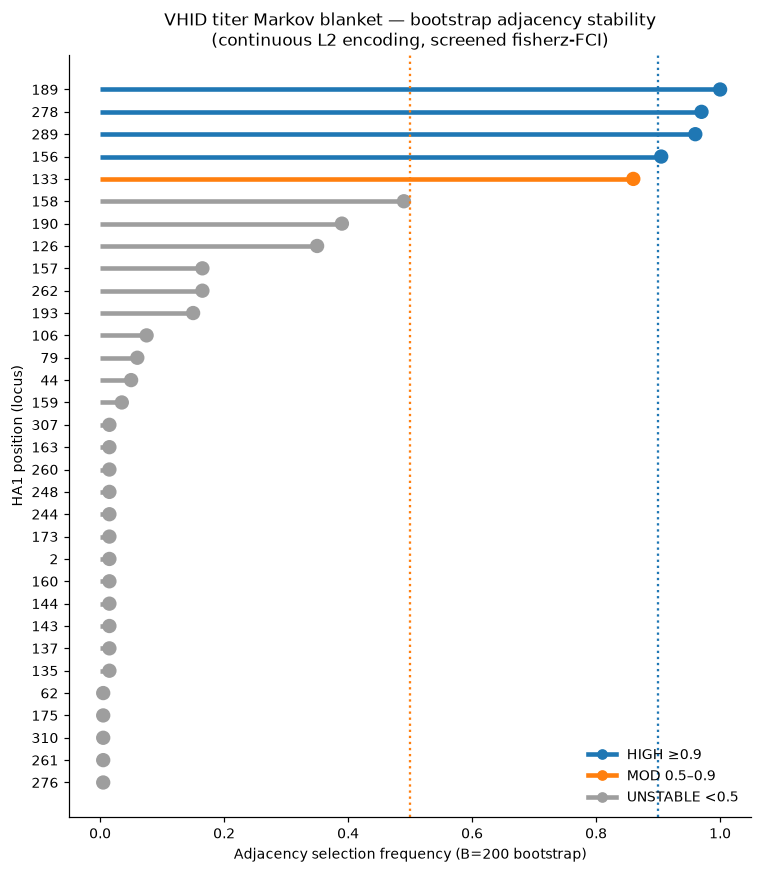

In [29]:
TCOL = {"HIGH": "#1f77b4", "MOD": "#ff7f0e", "UNSTABLE": "#9e9e9e"}
b = boot.sort_values("adjacency_selection_freq")
fig, ax = plt.subplots(figsize=(8, 9))
ax.hlines(b.position.astype(str), 0, b.adjacency_selection_freq,
          color=[TCOL[t] for t in b.tier], lw=3, zorder=1)
ax.scatter(b.adjacency_selection_freq, b.position.astype(str),
           color=[TCOL[t] for t in b.tier], s=70, zorder=2)
ax.axvline(0.9, ls=":", color="#1f77b4"); ax.axvline(0.5, ls=":", color="#ff7f0e")
ax.set_xlabel("Adjacency selection frequency (B=200 bootstrap)")
ax.set_ylabel("HA1 position (locus)")
ax.set_title("VHID titer Markov blanket \u2014 bootstrap adjacency stability\n"
             "(continuous L2 encoding, screened fisherz-FCI)")
from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([0],[0], color=TCOL["HIGH"], lw=3, marker="o", label="HIGH \u22650.9"),
                   Line2D([0],[0], color=TCOL["MOD"], lw=3, marker="o", label="MOD 0.5\u20130.9"),
                   Line2D([0],[0], color=TCOL["UNSTABLE"], lw=3, marker="o", label="UNSTABLE <0.5")],
          loc="lower right", frameon=False)
high = boot.loc[boot.tier == "HIGH", "position"].tolist()
print("HIGH-stability titer Markov blanket:", sorted(high))
plt.show()


In [30]:
boot.reset_index(drop=True)

Out[30]: 
      locus  position  adjacency_selection_freq      tier
0   pos_189       189                     1.000      HIGH
1   pos_278       278                     0.970      HIGH
2   pos_289       289                     0.960      HIGH
3   pos_156       156                     0.905      HIGH
4   pos_133       133                     0.860       MOD
5   pos_158       158                     0.490  UNSTABLE
6   pos_190       190                     0.390  UNSTABLE
7   pos_126       126                     0.350  UNSTABLE
8   pos_157       157                     0.165  UNSTABLE
9   pos_262       262                     0.165  UNSTABLE
10  pos_193       193                     0.150  UNSTABLE
11  pos_106       106                     0.075  UNSTABLE
12   pos_79        79                     0.060  UNSTABLE
13   pos_44        44                     0.050  UNSTABLE
14  pos_159       159                     0.035  UNSTABLE
15  pos_307       307                     0.015  UNSTABLE
16  

,locus,position,adjacency_selection_freq,tier
0,pos_189,189,1.000,HIGH
1,pos_278,278,0.970,HIGH
2,pos_289,289,0.960,HIGH
3,pos_156,156,0.905,HIGH
4,pos_133,133,0.860,MOD
5,pos_158,158,0.490,UNSTABLE
6,pos_190,190,0.390,UNSTABLE
7,pos_126,126,0.350,UNSTABLE
8,pos_157,157,0.165,UNSTABLE
9,pos_262,262,0.165,UNSTABLE


## 4. Conclusion

We set out to separate the HA positions that cause antigenic drift from those that merely accompany it, using methods whose outputs a biologist can inspect and a modeler can trust, and the honest reading of what we achieved is narrower than that goal but useful in its own right. Run on hemagglutination-inhibition titers alone, with no structural prior beyond the sink orientation, the pipeline concentrates its selected positions on the classical head antigenic sites — the residues serology and structural biology already implicate in escape — and it does so reproducibly across two independent datasets. In VHID H3N2 the positions that survive as high-stability under both the binary and the continuous physicochemical encoding are mature 156, 189, and 289; in the Bedford panel the convergent trio maps to mature 133, 158, and 189 (alignment columns 143, 168, 199), with 157 and 193 (columns 167, 203) close behind. In canonical H3 numbering these fall in antigenic site B (156–160 and 187–198, flanking the receptor-binding site) and site A (133), and Bedford column 168 → mature 158 and column 199 → mature 189 coincide exactly with the VHID mature-158 and mature-189 selections once the alignment-column offset is removed — a correction that also retires the earlier "site D" label, which was an artifact of reading columns 167/168 as mature residue numbers rather than the mature 157/158 they actually denote, both site B. Position 189 is a well-known determinant of H3N2 antigenic cluster transitions (Koel et al. 2013), so recovering it, and its neighbors, from titers alone is reassuring: it tells us the feature matrix is tracking real antigenic biology and not a dataset idiosyncrasy. What it does not tell us, and what we are careful not to claim, is that the causal machinery has been validated. Hemagglutination-inhibition titer is by construction a readout of antibody binding to these very sites, so any method that extracts antigenic signal — gradient boosting, univariate association, or a constraint-based causal search — will land on the same residues; the coincidence with known epitopes is therefore necessary evidence that the associations are biologically real, but it is not evidence that the causal step added identification over and above association, and we do not present it as such.

That distinction matters because our own validation constrains how strongly the selected positions can be called drivers. The Shipley d-separation goodness-of-fit test rejects the pure titer-sink star on both datasets: the retained positions are not mutually independent given the graph, because they co-evolve along a shared phylogeny, and the star encodes which loci are direct-cause candidates without capturing the residual dependence among them. For this reason the per-position effect sizes of the backdoor analysis are reported as partial-regression coefficients rather than identified causal effects. Read that way they are still informative. Every adjusted effect is smaller in magnitude than its marginal counterpart, none flips sign under adjustment, and all bootstrap confidence intervals exclude zero — a shrinkage consistent with removing phylogenetic confounding shared among co-evolving sites, though, because the structure is goodness-of-fit-rejected and the parents are densely inter-adjacent, equally consistent with conditioning on a mediator or a collider, a distinction the observational data cannot settle. The one position whose effect is positive in both the marginal and the adjusted estimate is VHID mature 289, where a larger physicochemical substitution associates with a higher cross-titer — the opposite of an escape signature — which, together with its location outside any classical antigenic site, is consistent with a compensatory or stability-restoring role rather than direct epitope escape. We offer that as a hypothesis to be tested against structural and deep-mutational-scanning evidence, not as a causal finding. The same hedging applies to two further positions that the magnitude-weighted continuous encoding promotes to high stability where the binary flag did not: mature 278, which sits in antigenic site C on the membrane-distal face near the vestigial esterase subdomain, a plausible but less-studied escape locus; and again 289. Both readings rest on a continuous-encoding adjacency that is not orientable — since titer is a pure sink, edges into it cannot be directed from conditional-independence structure — and neither is corroborated by the binary discovery, so both are hypotheses rather than claims. The encoding comparison cuts the other way as well, and we report it plainly: mature 158, a canonical site-B residue and a Koel-2013 cluster-transition position that is a high-stability driver under the binary encoding (bootstrap 0.95), drops to unstable (0.490) once substitutions are weighted by physicochemical magnitude rather than counted as present or absent. That headline residue is therefore encoding-fragile, and we present it as the clearest illustration of how much the selected set can depend on how a substitution is scored, not as a settled driver.

Where the data cannot support residue-level attribution at all, the limiting factor is linkage. In H3N2 the largest pre-collapse block of co-evolving positions spans 88 residues and a second spans 55; these absorb many head positions into single clade-linked units that no observational method can resolve internally, which is also why H3N2 has the lowest predictive ceiling of the two datasets. A claim for a position inside such a block — H3N2 position 11 is the example — belongs to the block, not the single residue, and separating them would require strains sampled across genetic backgrounds that break the linkage. Two further caveats bound the causal reading. The conditional-independence tests use a Gaussian, Fisher-z working model because the discrete test is intractable at this scale, so purely nonlinear dependences can be missed by the constraint step; the Kolmogorov–Arnold Network partially covers this gap on the predictive side, and the nonparametric kernel re-test makes the risk concrete, flagging H3N2 mature 159 (site B) as dependent on titer under the kernel test while it looked independent under Fisher-z — a nonlinear direct-cause candidate the linear pipeline would have discarded. And because PC assumes causal sufficiency and FCI was run only for VHID, unmeasured drivers — neuraminidase, glycosylation, non-HA1 regions, and the receptor-avidity and NA-activity contributions that HI titer folds in alongside head-epitope binding — remain possible confounders. All causal results are accordingly reported as bootstrap-ranked equivalence-class candidates under a Gaussian working model, never as a single settled graph, and "stability" throughout is a property of the selection procedure rather than of causal correctness: a hitchhiker tightly linked to a true driver is selected in nearly every bootstrap for exactly the wrong reason.

It also follows that the promise most naturally attached to this work — anticipating escape for strains never seen serologically — is not something we have demonstrated, and we say so directly rather than list it only as future work. The out-of-distribution transport panel was removed, and with it went the only test that spoke to whether the discovered structure carries transportable causal content; no surviving test does. The closest present-day evidence of generalization is the leakage-free grouped cross-validation, and that is also the number a downstream user should hold in mind, not the random-split values inflated by strain and serum recurrence. Under the strictest and most realistic grouping — predicting titers against a reference antiserum held out entirely — the strongest method reaches a median R² of roughly 0.61 on VHID and 0.50 on H3N2, well below the random-split figures near 0.85 and 0.61. That is the honest predictive headline, and it is modest; transportability of the causal structure, as opposed to the associations, is currently unevaluated.

The natural next steps are the ones that would convert these hedges into evidence. Mapping the convergent positions onto HA head structure, from experimental or predicted models, would let the epitope-alteration and stability hypotheses — particularly for 278 and 289 — be tested rather than asserted. Adding strains that decouple the large H3N2 linkage blocks, or folding deep-mutational-scanning escape maps in as interventional data, would move the analysis from observational discovery toward identified effects and is the only route that can resolve within-block attribution. A time-resolved or explicitly non-stationary effect model would test whether driver identities and magnitudes are stable across collection eras or drift with antigenic evolution, the natural successor now that the era-transport panel has been removed. Extending the framework to the Bedford H1N1, B/Yamagata, and B/Victoria panels would test whether the convergence generalizes beyond H3N2, and constraining the network's inputs to the selected positions would yield a predictor whose importances are causal by construction — if the causal reading survives the structural and interventional follow-up above. Returning to the decision that opened this study, the twice-yearly bet on which strains next season's vaccine should target, the contribution here is not a more accurate predictor but a more honest one: a model that names which residues its predictions lean on, reports how encoding-sensitive and how stable each of those choices is, and separates the part of each association that survives controlling for co-evolving sites from the part that does not. That the selected positions rediscover the classical head epitopes from titers alone is evidence the features are tracking real biology; that we cannot yet show the selection is causal, transportable, or robust to how substitutions are scored is a map of exactly where structural work, denser sampling, and intervention must take over. Reading antigenic distance from sequence remains the goal; reading its causes from sequence is the harder step that would let surveillance anticipate escape rather than only measure it, and this study marks honestly how far along that step the current data can carry us.

## 5. References

1. **Smith, D. J., Lapedes, A. S., de Jong, J. C., Bestebroer, T. M., Rimmelzwaan,
   G. F., Osterhaus, A. D. M. E., Fouchier, R. A. M.** (2004). Mapping the antigenic
   and genetic evolution of influenza virus. *Science* **305**(5682), 371–376.
2. **Bedford, T., Suchard, M. A., Lemey, P., Dudas, G., Gregory, V., Hay, A. J.,
   McCauley, J. W., Russell, C. A., Smith, D. J., Rambaut, A.** (2014). Integrating
   influenza antigenic dynamics with molecular evolution. *eLife* **3**, e01914.
3. **Du, E., Zhong, Z., Wang, P., et al.** (2023). DPCIPI: A pre-trained deep learning
   model for predicting cross-immunity between drifted strains of Influenza A/H3N2.
   *arXiv:2302.00926.*
4. **Grantham, R.** (1974). Amino acid difference formula to help explain protein
   evolution. *Science* **185**(4154), 862–864.
5. **Spirtes, P., Glymour, C., Scheines, R.** (2000). *Causation, Prediction, and
   Search* (2nd ed.). MIT Press. (PC algorithm.)
6. **Chickering, D. M.** (2002). Optimal structure identification with greedy search.
   *Journal of Machine Learning Research* **3**, 507–554. (GES.)
7. **Zhang, J.** (2008). On the completeness of orientation rules for causal discovery
   in the presence of latent confounders and selection bias. *Artificial Intelligence*
   **172**(16–17), 1873–1896. (FCI.)
8. **Liu, Z., Wang, Y., Vaidya, S., et al.** (2024). KAN: Kolmogorov–Arnold Networks.
   *arXiv:2404.19756.*
9. **Pearl, J.** (2009). *Causality: Models, Reasoning, and Inference* (2nd ed.).
   Cambridge University Press. (Backdoor adjustment / do-calculus.)
10. **Chen, T., Guestrin, C.** (2016). XGBoost: A scalable tree boosting system.
    *KDD 2016*, 785–794.
11. **Koel, B. F., Burke, D. F., Bestebroer, T. M., van der Vliet, S., Zondag, G. C. M.,
    Vervaet, G., Skepner, E., Lewis, N. S., Spronken, M. I. J., Russell, C. A., Eropkin,
    M. Y., Hurt, A. C., Barr, I. G., de Jong, J. C., Rimmelzwaan, G. F., Osterhaus, A. D.
    M. E., Fouchier, R. A. M., Smith, D. J.** (2013). Substitutions near the receptor
    binding site determine major antigenic change during influenza virus evolution.
    *Science* **342**(6161), 976–979.
12. **Neher, R. A., Bedford, T., Daniels, R. S., Russell, C. A., Shraiman, B. I.** (2016).
    Prediction, dynamics, and visualization of antigenic phenotypes of seasonal influenza
    viruses. *Proceedings of the National Academy of Sciences* **113**(12), E1701–E1709.
13. **Łuksza, M., Lässig, M.** (2014). A predictive fitness model for influenza. *Nature*
    **507**(7490), 57–61.
14. **Harvey, W. T., Benton, D. J., Gregory, V., Hall, J. P. J., Daniels, R. S., Bedford,
    T., Haydon, D. T., Hay, A. J., McCauley, J. W., Reeve, R.** (2016). Identification of
    low- and high-impact hemagglutinin amino acid substitutions that drive antigenic drift
    of influenza A(H3N2) viruses. *PLoS Pathogens* **12**(4), e1005526.
15. **Wiley, D. C., Wilson, I. A., Skehel, J. J.** (1981). Structural identification of the
    antibody-binding sites of Hong Kong influenza haemagglutinin and their involvement in
    antigenic variation. *Nature* **289**(5796), 373–378.
16. **Caton, A. J., Brownlee, G. G., Yewdell, J. W., Gerhard, W.** (1982). The antigenic
    structure of the influenza virus A/PR/8/34 hemagglutinin (H1 subtype). *Cell* **31**(2),
    417–427.
17. **Doud, M. B., Lee, J. M., Bloom, J. D.** (2018). How single mutations affect viral
    escape from broad and narrow antibodies to H1 influenza hemagglutinin. *Nature
    Communications* **9**, 1386.
18. **Lee, J. M., Eguia, R., Zost, S. J., Choudhary, S., Wilson, P. C., Bedford, T.,
    Stevens-Ayers, T., Boeckh, M., Hurt, A. C., Lakdawala, S. S., Hensley, S. E., Bloom,
    J. D.** (2019). Mapping person-to-person variation in viral mutations that escape
    polyclonal serum targeting influenza hemagglutinin. *eLife* **8**, e49324.
19. **Lou, Y., Caruana, R., Gehrke, J., Hooker, G.** (2013). Accurate intelligible models
    with pairwise interactions. *KDD 2013*, 623–631.

---

*Data: `influenza-hi-antigenic-distance` repository (CC0). Code and this notebook are
released alongside it. Causal discovery uses the `causal-learn` library; the KAN is a
custom PyTorch implementation in `src/bspline_kan.py`. The full pipeline — linkage
collapse, causal discovery, B-spline KAN, and cross-method convergence — is packaged
as the reusable `kan-causal-antigenic-workflow` skill.*